# Agent and Environment

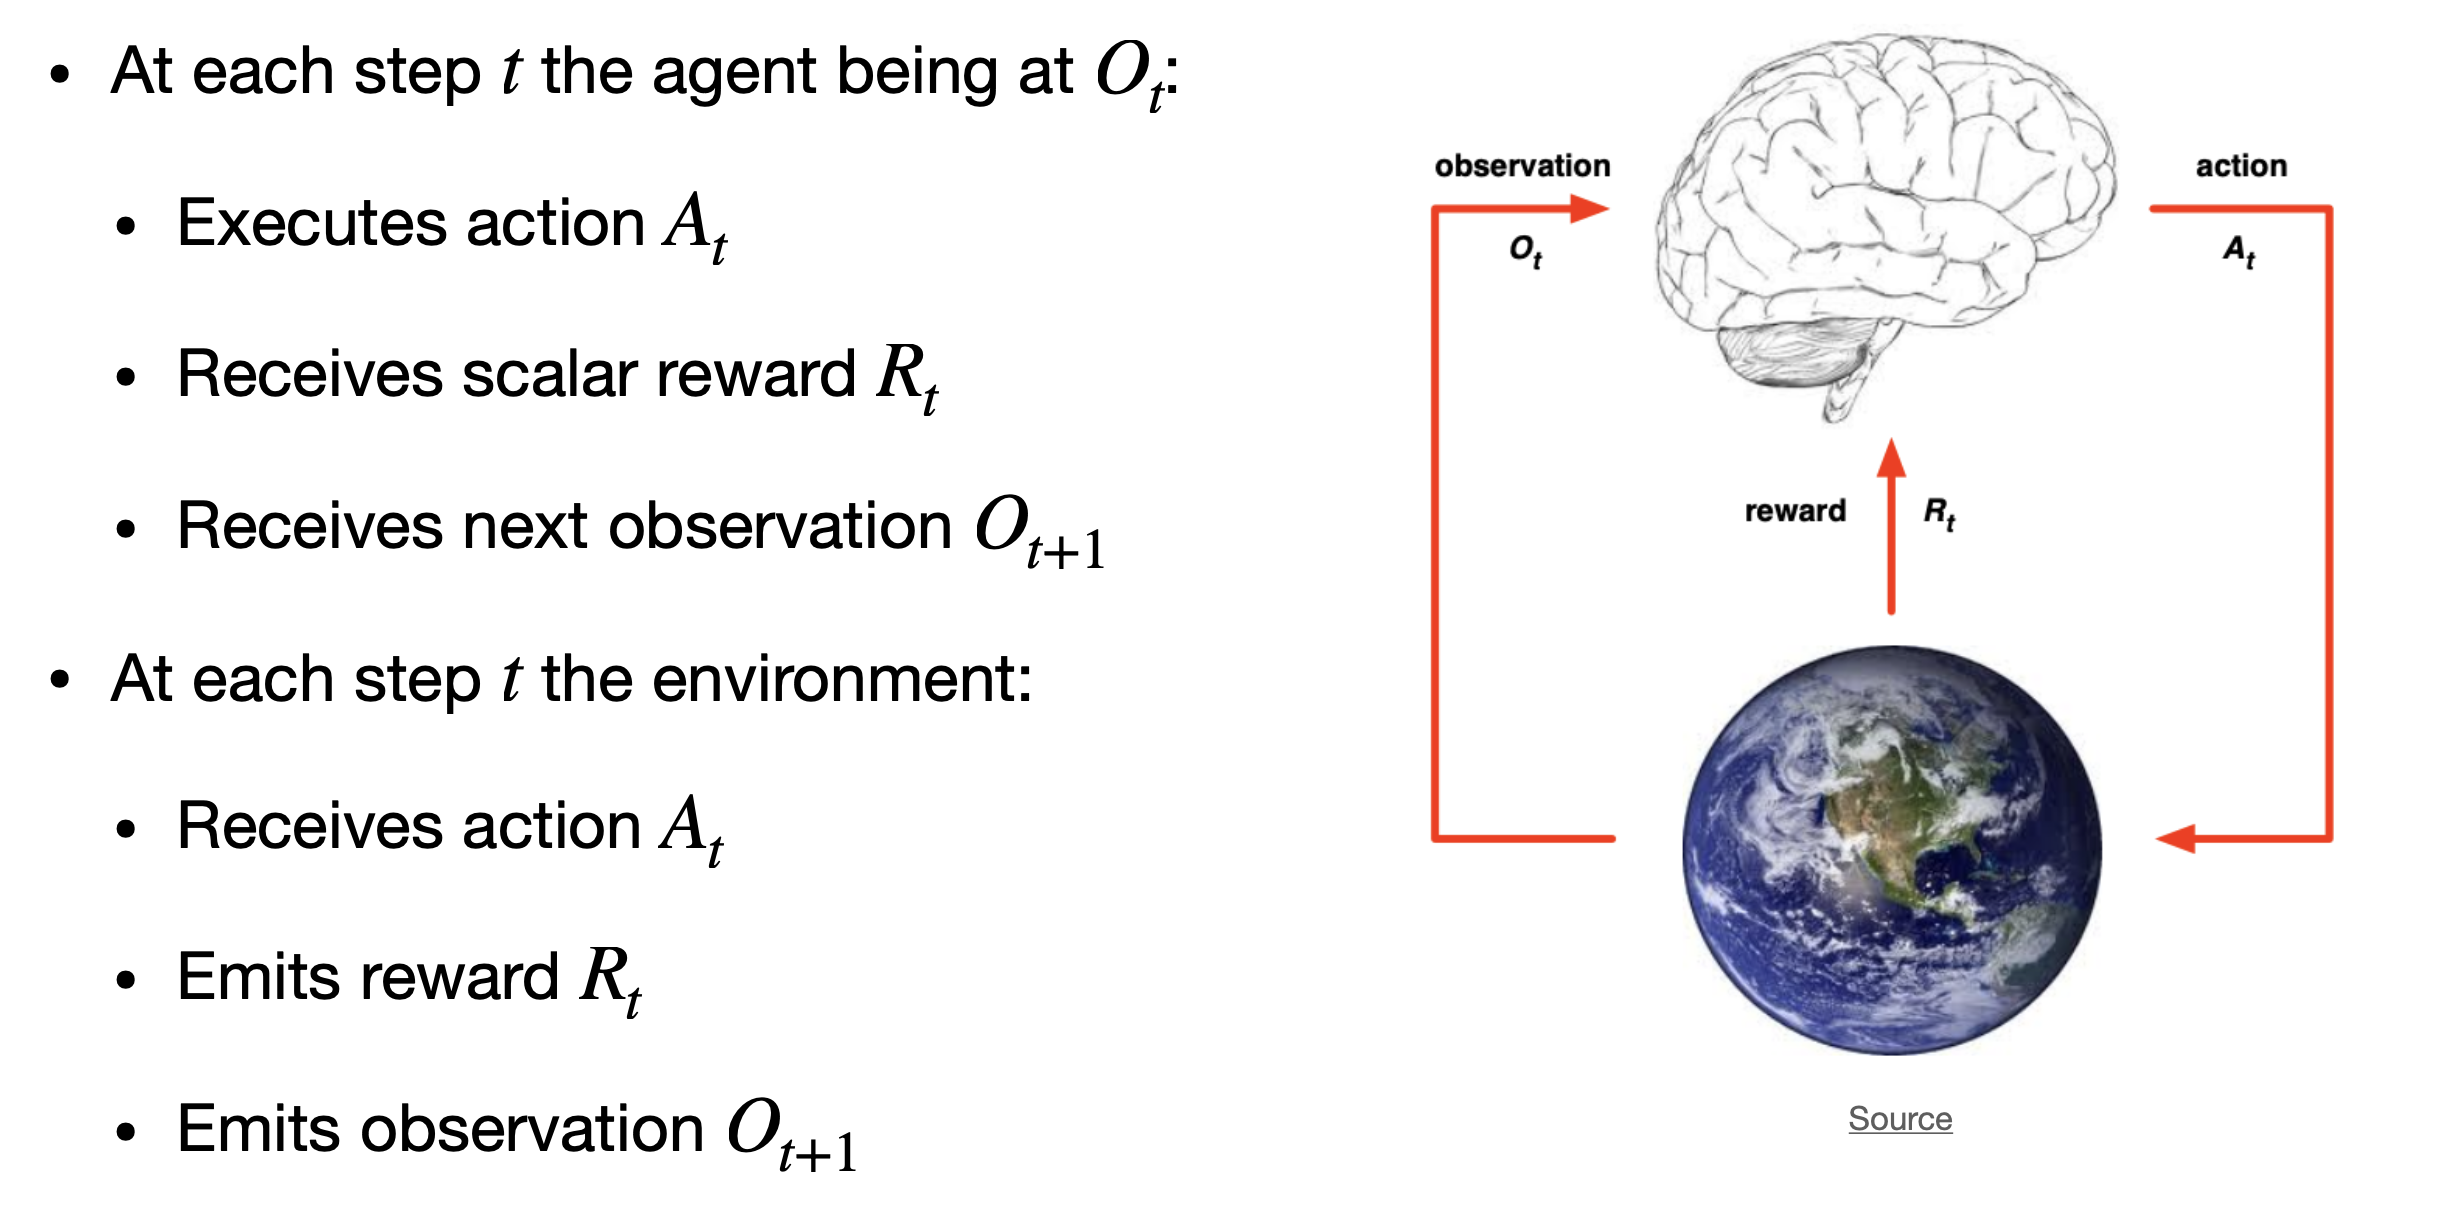

# State
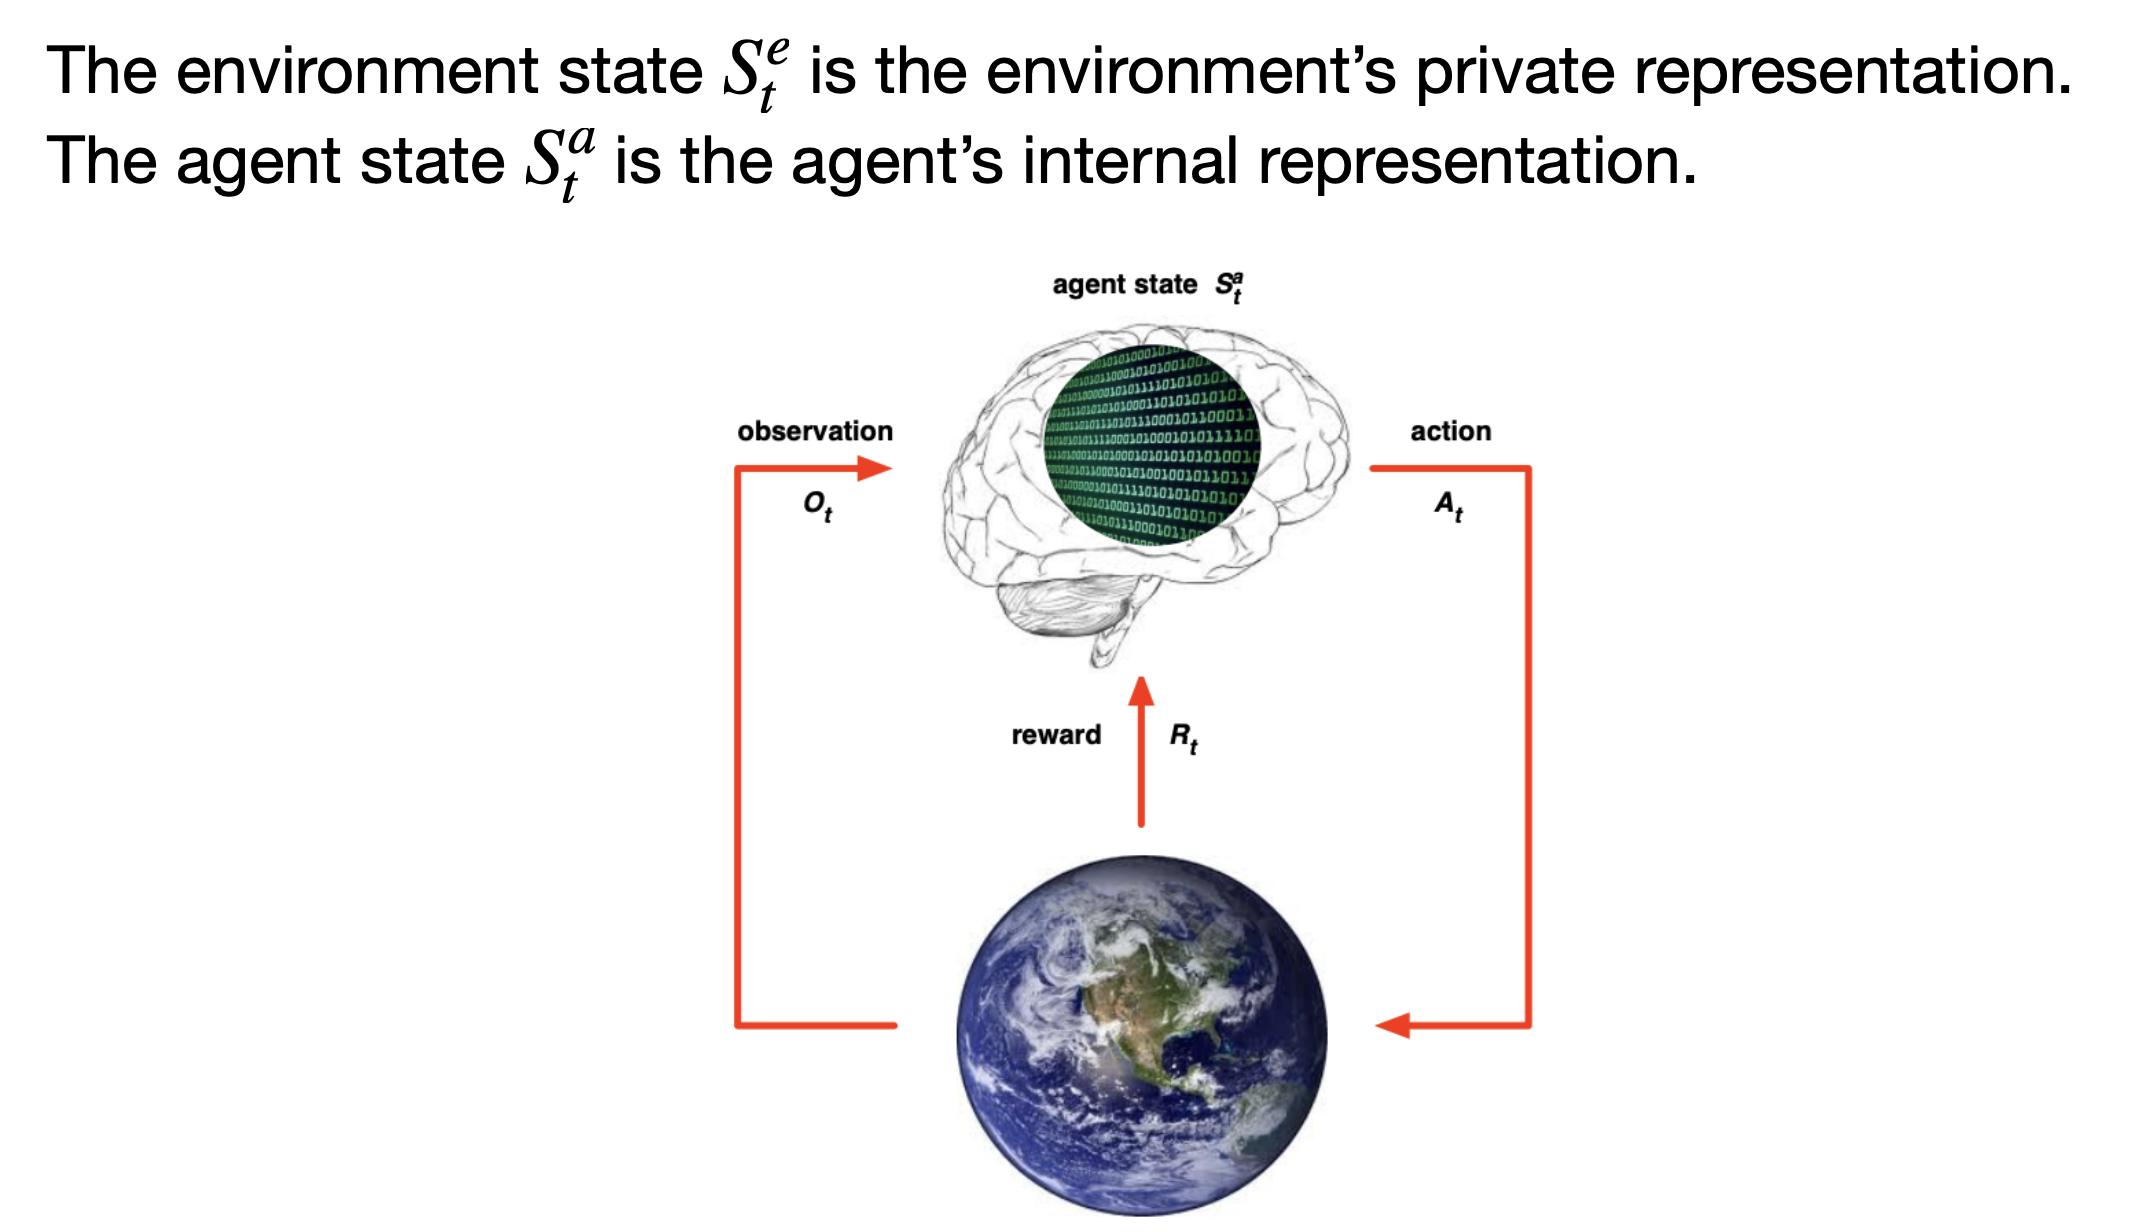


### **Состояния**
> Состояние среды $ S_t^e $ — это внутреннее (скрытое) представление среды.  
> Состояние агента $ S_t^a $ — это внутреннее представление агента.


### **Обозначения и пояснения:**

- **$ O_t $** — *наблюдение* в момент времени $ t $: это то, что агент «видит» от среды. Это может быть неполная информация о реальном состоянии среды $ S_t^e $.
- **$ A_t $** — *действие*, совершаемое агентом в момент времени $ t $.
- **$ R_t $** — *награда*, которую агент получает за действие.
- **$ S_t^e $** — *истинное состояние среды*, возможно, полностью недоступное агенту.
- **$ S_t^a $** — *внутреннее состояние агента*, например, скрытые слои в нейронной сети или параметры модели, которые он использует для принятия решений.


### **Смысл:**

На этом слайде показано, что агент не имеет прямого доступа к полному состоянию среды $ S_t^e $. Он получает только наблюдение $ O_t $, из которого формирует своё внутреннее представление $ S_t^a $, на основе которого принимает решение о действии $ A_t $. Это особенно важно в **частично наблюдаемых средах (POMDP)**, где агент не может наблюдать всё состояние среды напрямую.


**Условное разграниечине понятий:**

1. Сотосяние всех атомов во вселенной это $ S_t^e $
2. Состояние всех атомов в окресности, например автомобиля, которые он может наблюдать.
3. Это показание приборов, то есть $ S_t^a $

# Observation

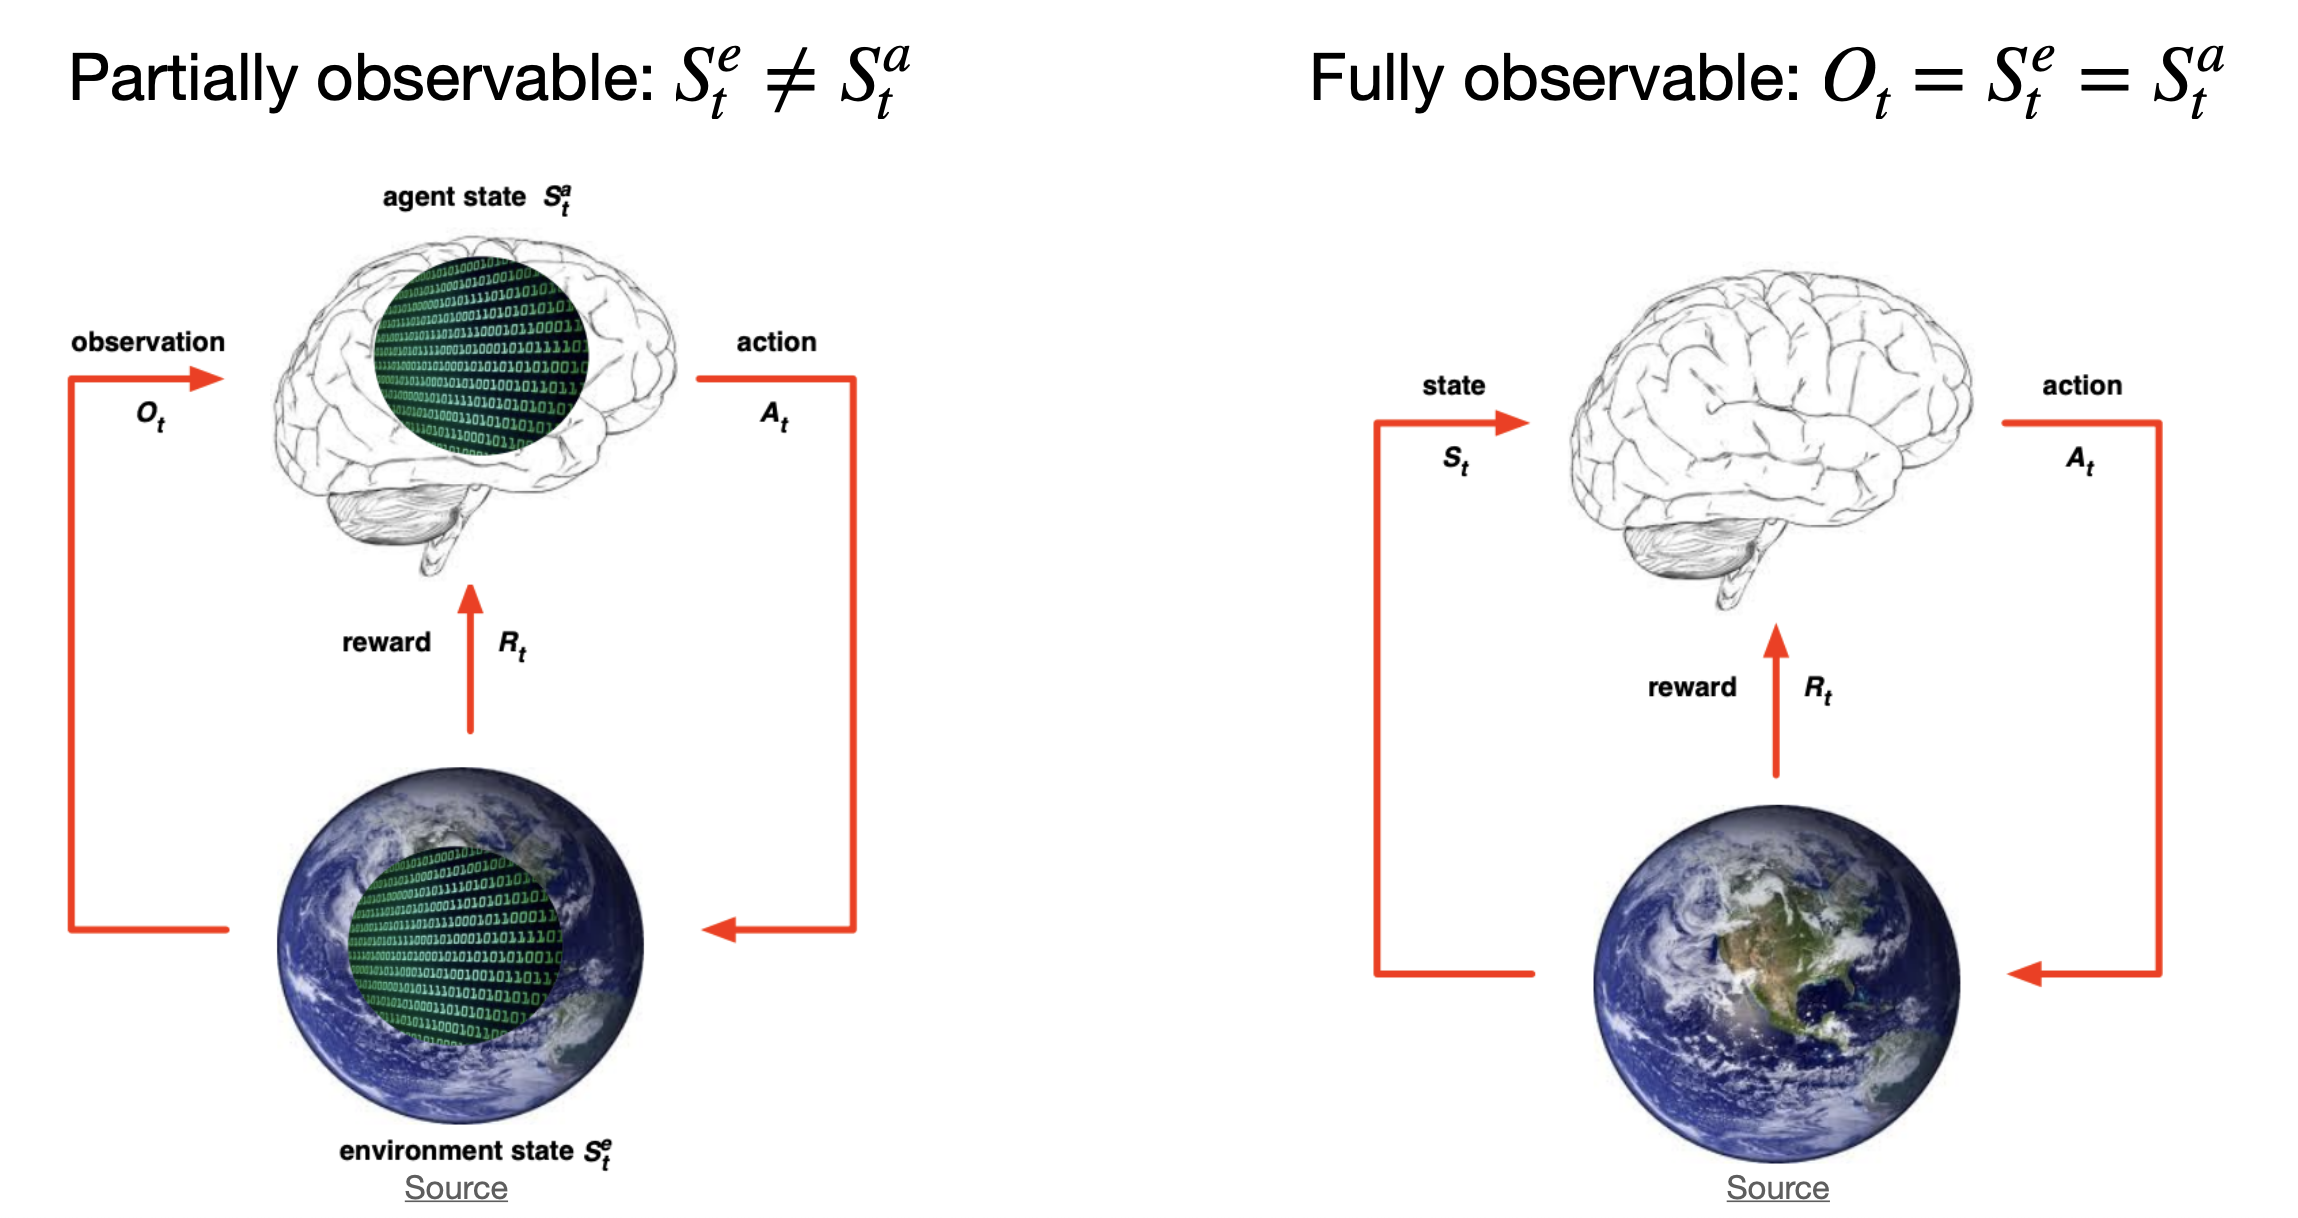

#### **Слева: Частичная наблюдаемость (Partially Observable)**
- Агент **не видит всё состояние среды**.
- Он получает лишь наблюдение $ O_t $, которое **не содержит полной информации** о состоянии среды $ S_t^e $.
- Поэтому он строит своё **внутреннее представление** $ S_t^a $, чтобы как-то компенсировать недостающую информацию.

#### **Справа: Полная наблюдаемость (Fully Observable)**
- Агент **полностью видит состояние среды**: наблюдение $ O_t $ = истинное состояние среды.
- Поэтому его внутреннее состояние $ S_t^a $ может быть тем же самым.
- Это называется **полностью наблюдаемая среда**, и она описывается как **MDP (Markov Decision Process)**.

# **Политика (Policy)**

- **Политика полностью определяет поведение агента**
- Это отображение из состояния в действие, например:

#### **Детерминированная политика** (Deterministic policy):  
$\large
a = \pi(s)
$  
Агент всегда выбирает одно и то же действие $ a $ в состоянии $ s $

#### **Стохастическая политика** (Stochastic policy):  
$\large
\pi(a \mid s) = P[A_t = a \mid S_t = s]
$  
Агент выбирает действие по вероятностному распределению: вероятность выбрать действие $ a $ в состоянии $ s $

# **Objective**

$$\large
\mathbb{E}_{\pi} \left[ \sum_{t=0}^{T} \gamma^t R_t \right] \rightarrow \max_{\pi}
$$

# 2. Markov Decision Process

## Процесс принятия решений Маркова (Markov Decision Process, MDP):

**Определения:**

1. **$\mathcal{A}$** — множество возможных действий (action space).

2. **$\mathcal{S}$** — множество возможных состояний (state space).

3. **Начальное распределение состояний:** начальное состояние $ s_0 $ выбирается из некоторого распределения $ p_0 $.

4. **$p(r, s' \mid s, a)$** — это вероятность получить награду $ r $ и перейти в следующее состояние $ s' $, при условии, что текущее состояние было $ s $, и было совершено действие $ a $:
$$\large
p(r, s' \mid s, a) = \mathbb{P}(R_t = r, S_{t+1} = s' \mid S_t = s, A_t = a)
$$

5. **Коэффициент дисконтирования $\gamma \in [0, 1]$** — это коэффициент, который определяет, насколько сильно учитываются будущие награды по сравнению с текущими. Чем он ближе к 0, тем менее важны отдалённые будущие награды. Чем ближе к 1, тем сильнее учитываются будущие награды.


## Свойство Маркова (Markov Property):

Это ключевая идея MDP, которая означает, что будущее не зависит от прошлого при условии текущего состояния. Формально это записывается следующим образом:

$
p(R_t, S_{t+1} \mid S_t, A_t, R_{t-1}, S_{t-1}, A_{t-1}, \dots) = p(R_t, S_{t+1} \mid S_t, A_t)
$

Это означает, что для определения вероятности следующего состояния и получаемой награды достаточно только текущего состояния и действия, и не нужны предыдущие состояния и действия.


## Простое пояснение сути:

MDP описывает ситуацию, когда агент находится в некотором состоянии $ s $, выполняет действие $ a $, после чего среда возвращает агенту награду $ r $ и переводит его в новое состояние $ s' $. Процесс называется марковским, потому что для того, чтобы принять решение, агенту важно только текущее состояние, а вся предыдущая история не имеет значения.

Такие процессы являются основой для обучения с подкреплением (reinforcement learning), где цель — выбрать стратегию действий, максимизирующую суммарную награду в долгосрочной перспективе.

# Non-markovian Environments

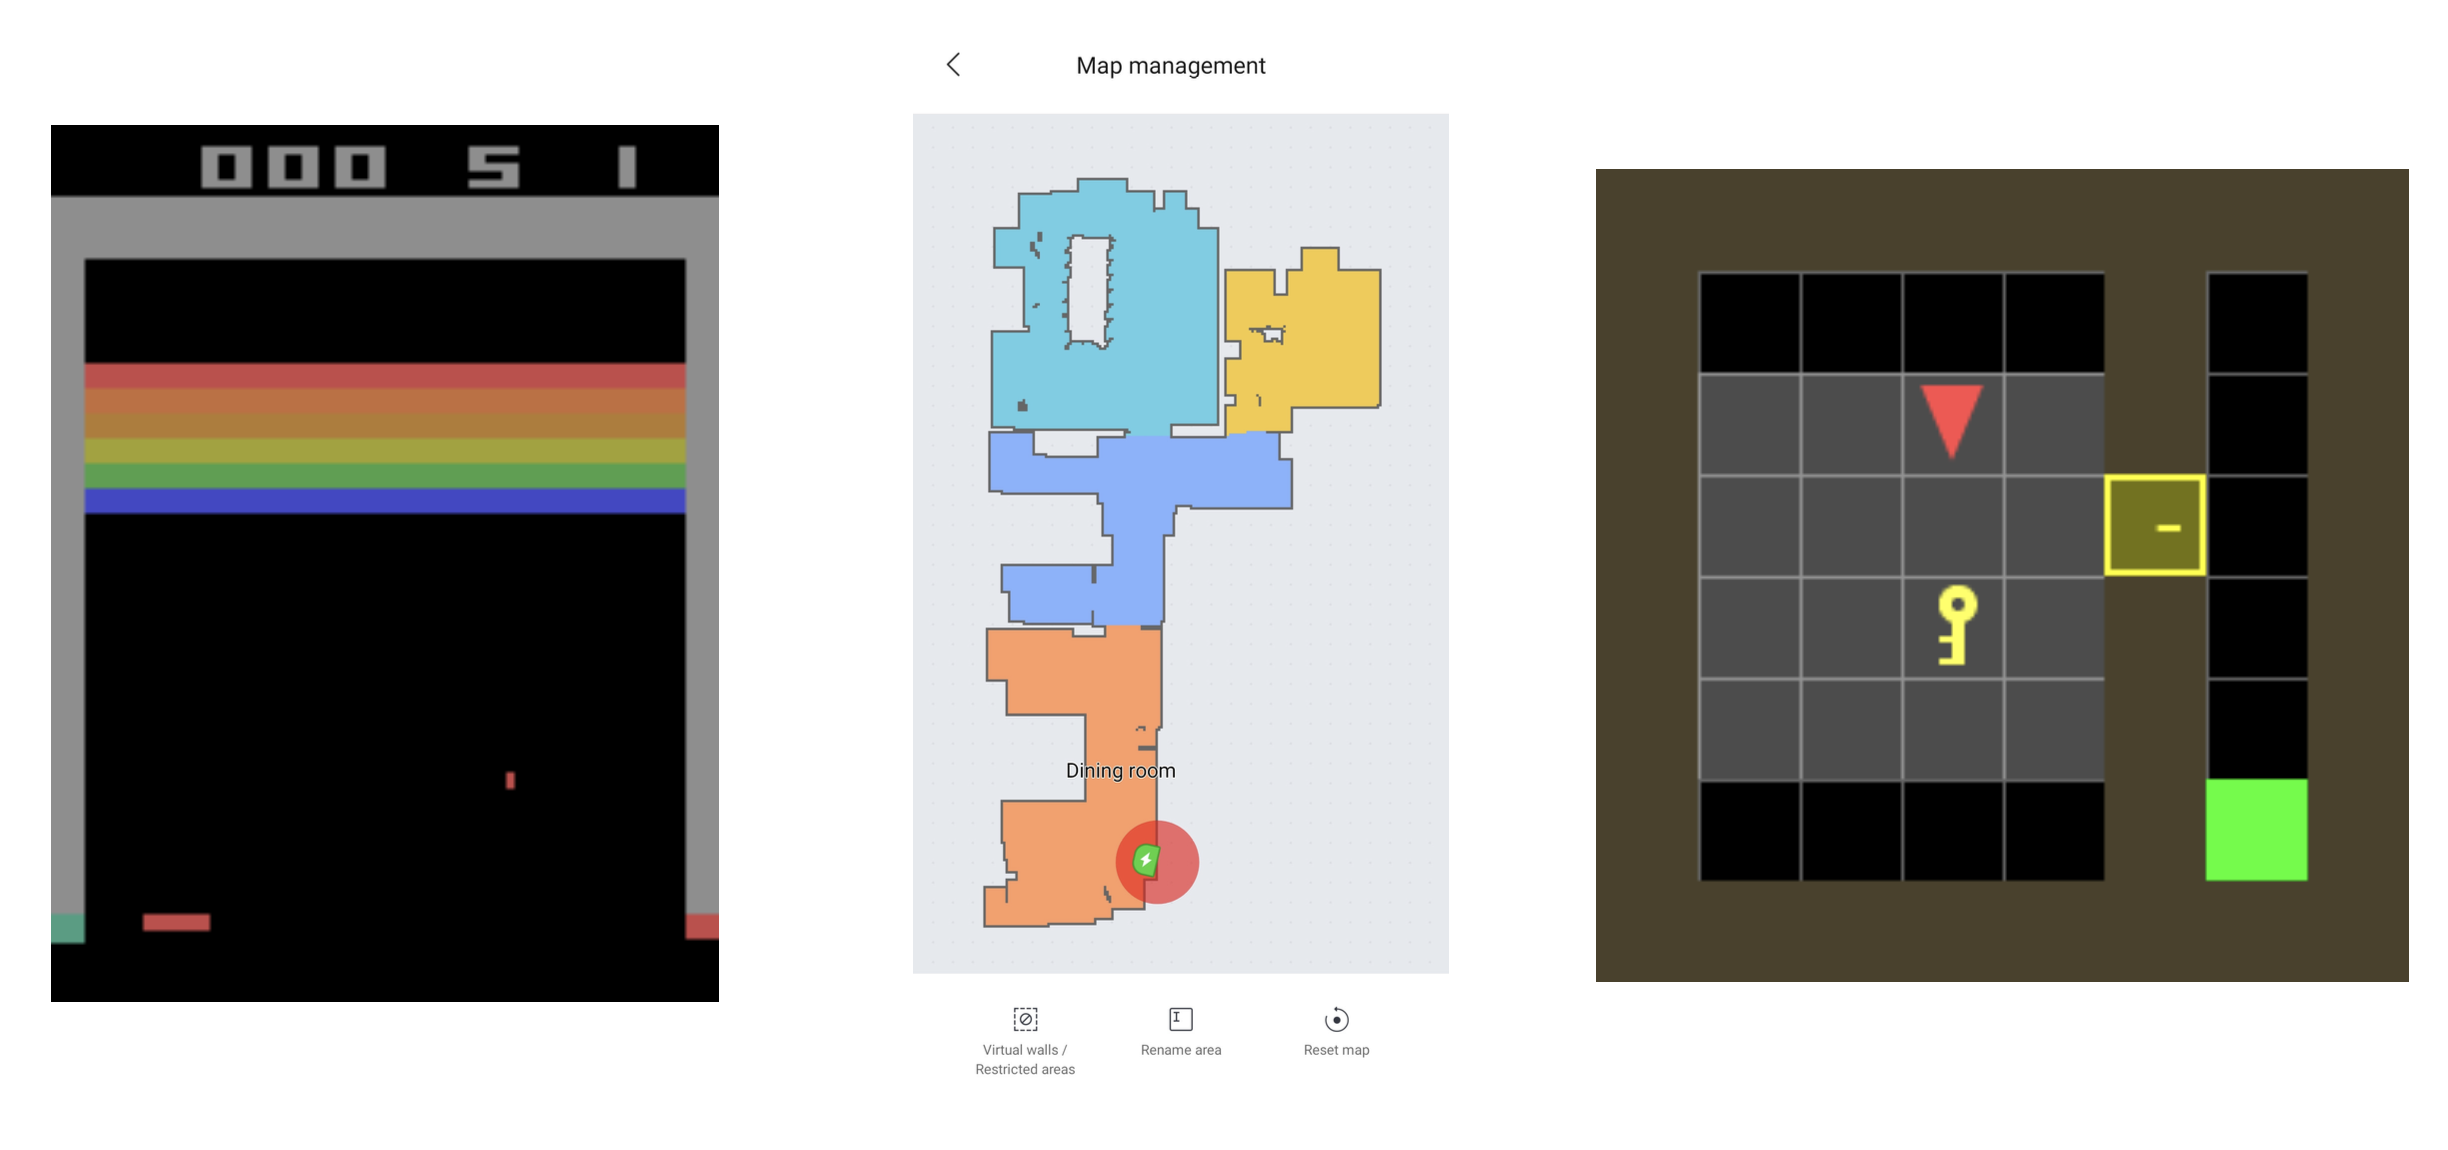

### Как превратить не марковскую среду в марковскую:

1. **История наблюдений**  
   Добавь несколько предыдущих кадров/шагов:  
   $ s_t = (o_t, o_{t-1}, \dots, o_{t-k}) $  
   → полезно в играх вроде Breakout (левое изображение), чтобы понять скорость мяча.

2. **RNN / Transformer**  
   Используй память (LSTM/GRU/Transformer), чтобы агрегировать прошлое в скрытое состояние.  
   → особенно эффективно в задачах навигации (правое изображение).

3. **Агрегированное состояние / карта**  
   Вместо частичных наблюдений сохраняй и обновляй глобальную карту + позицию.  
   → применимо для карт и роботов (среднее изображение).

# Equivalent Definition
Коментарий лектора: Множество действий и состояний остались такими же.
Динамика среды теперь задаётся стохастически только в следующем состоянии и считаем что среда детерминирована. Функция награды зависит только от текущего состояния и текущего действия. Мы говорим что сейчас r детерминирована, для упрощения выкладок.

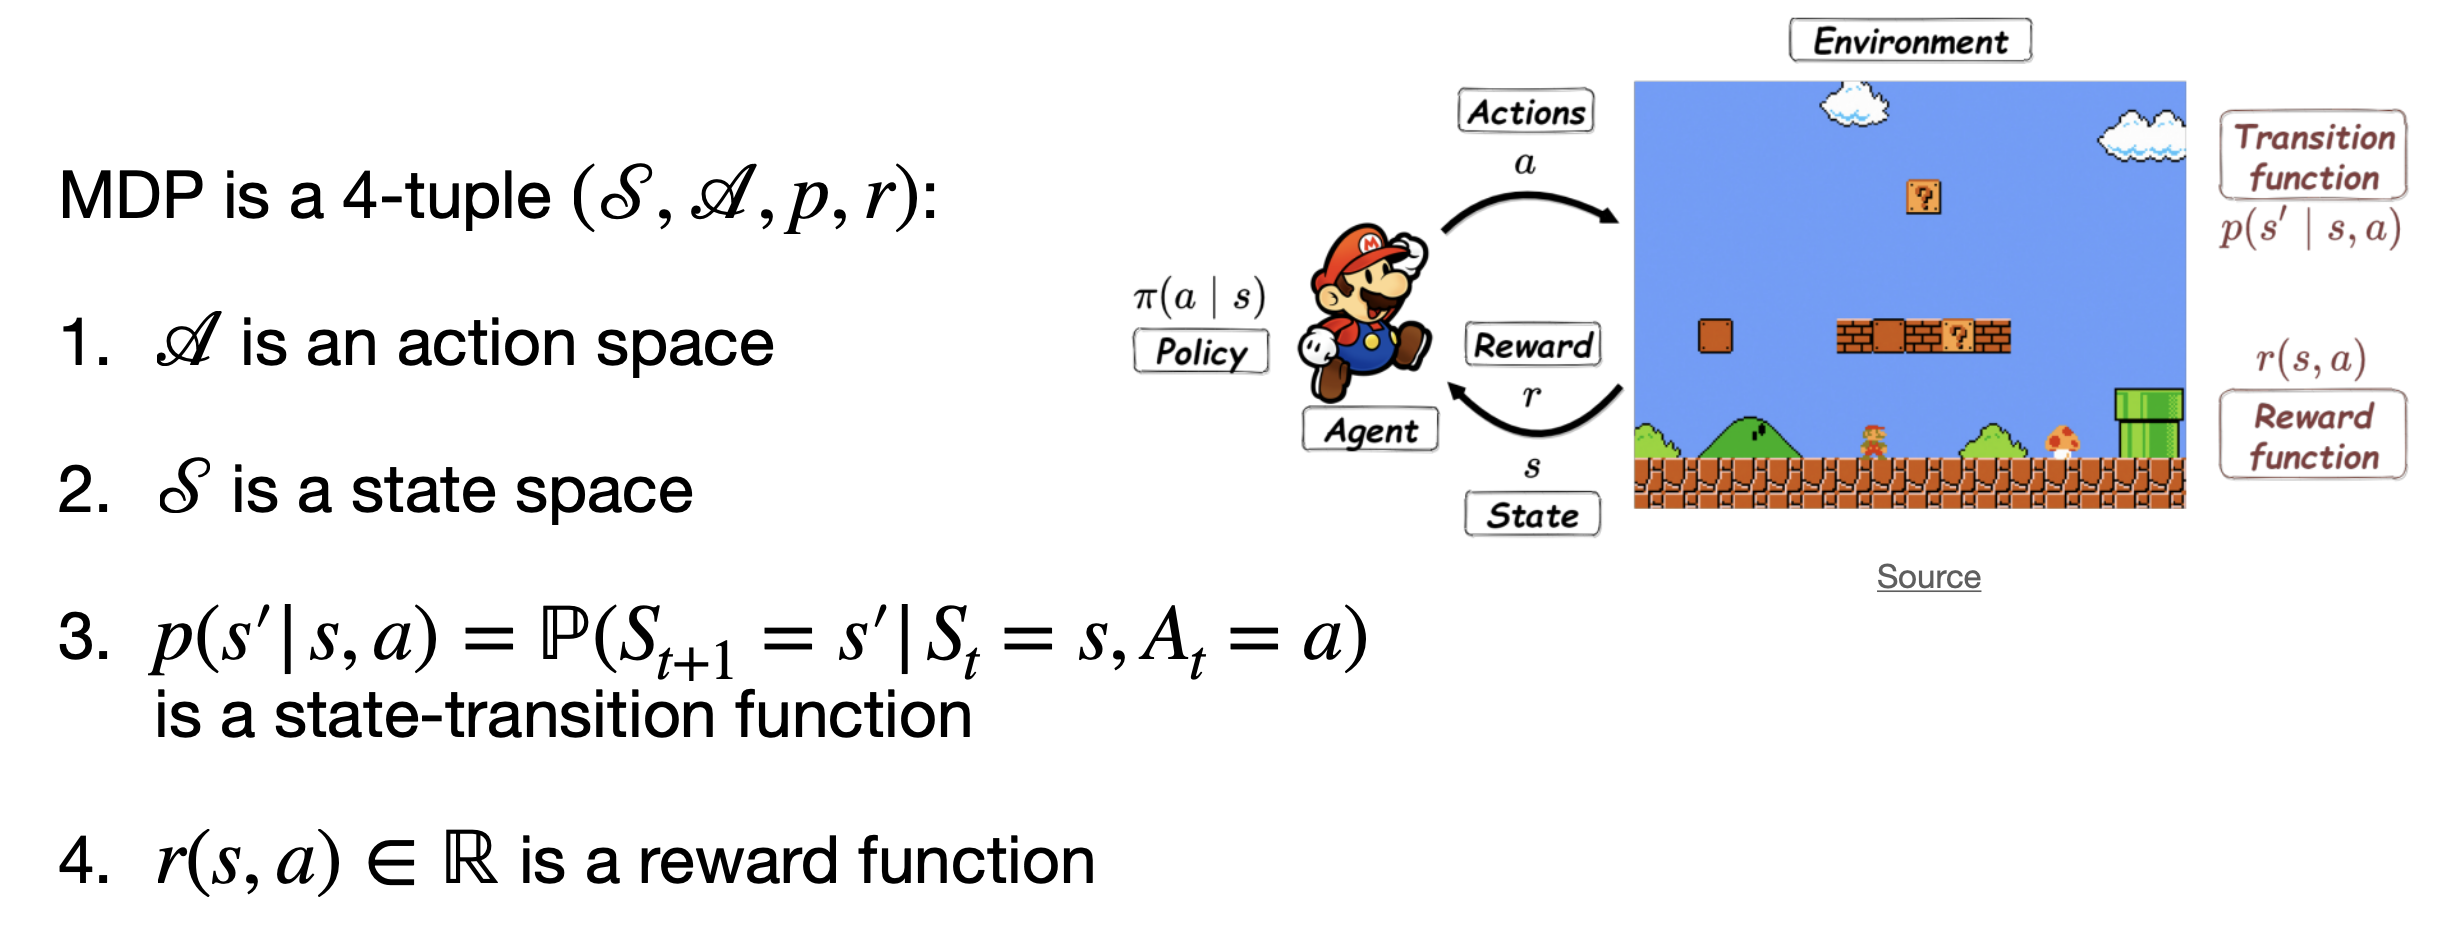

https://chatgpt.com/c/6808e591-0610-8006-bc65-00504cf74f1e

# Example: Student MDP

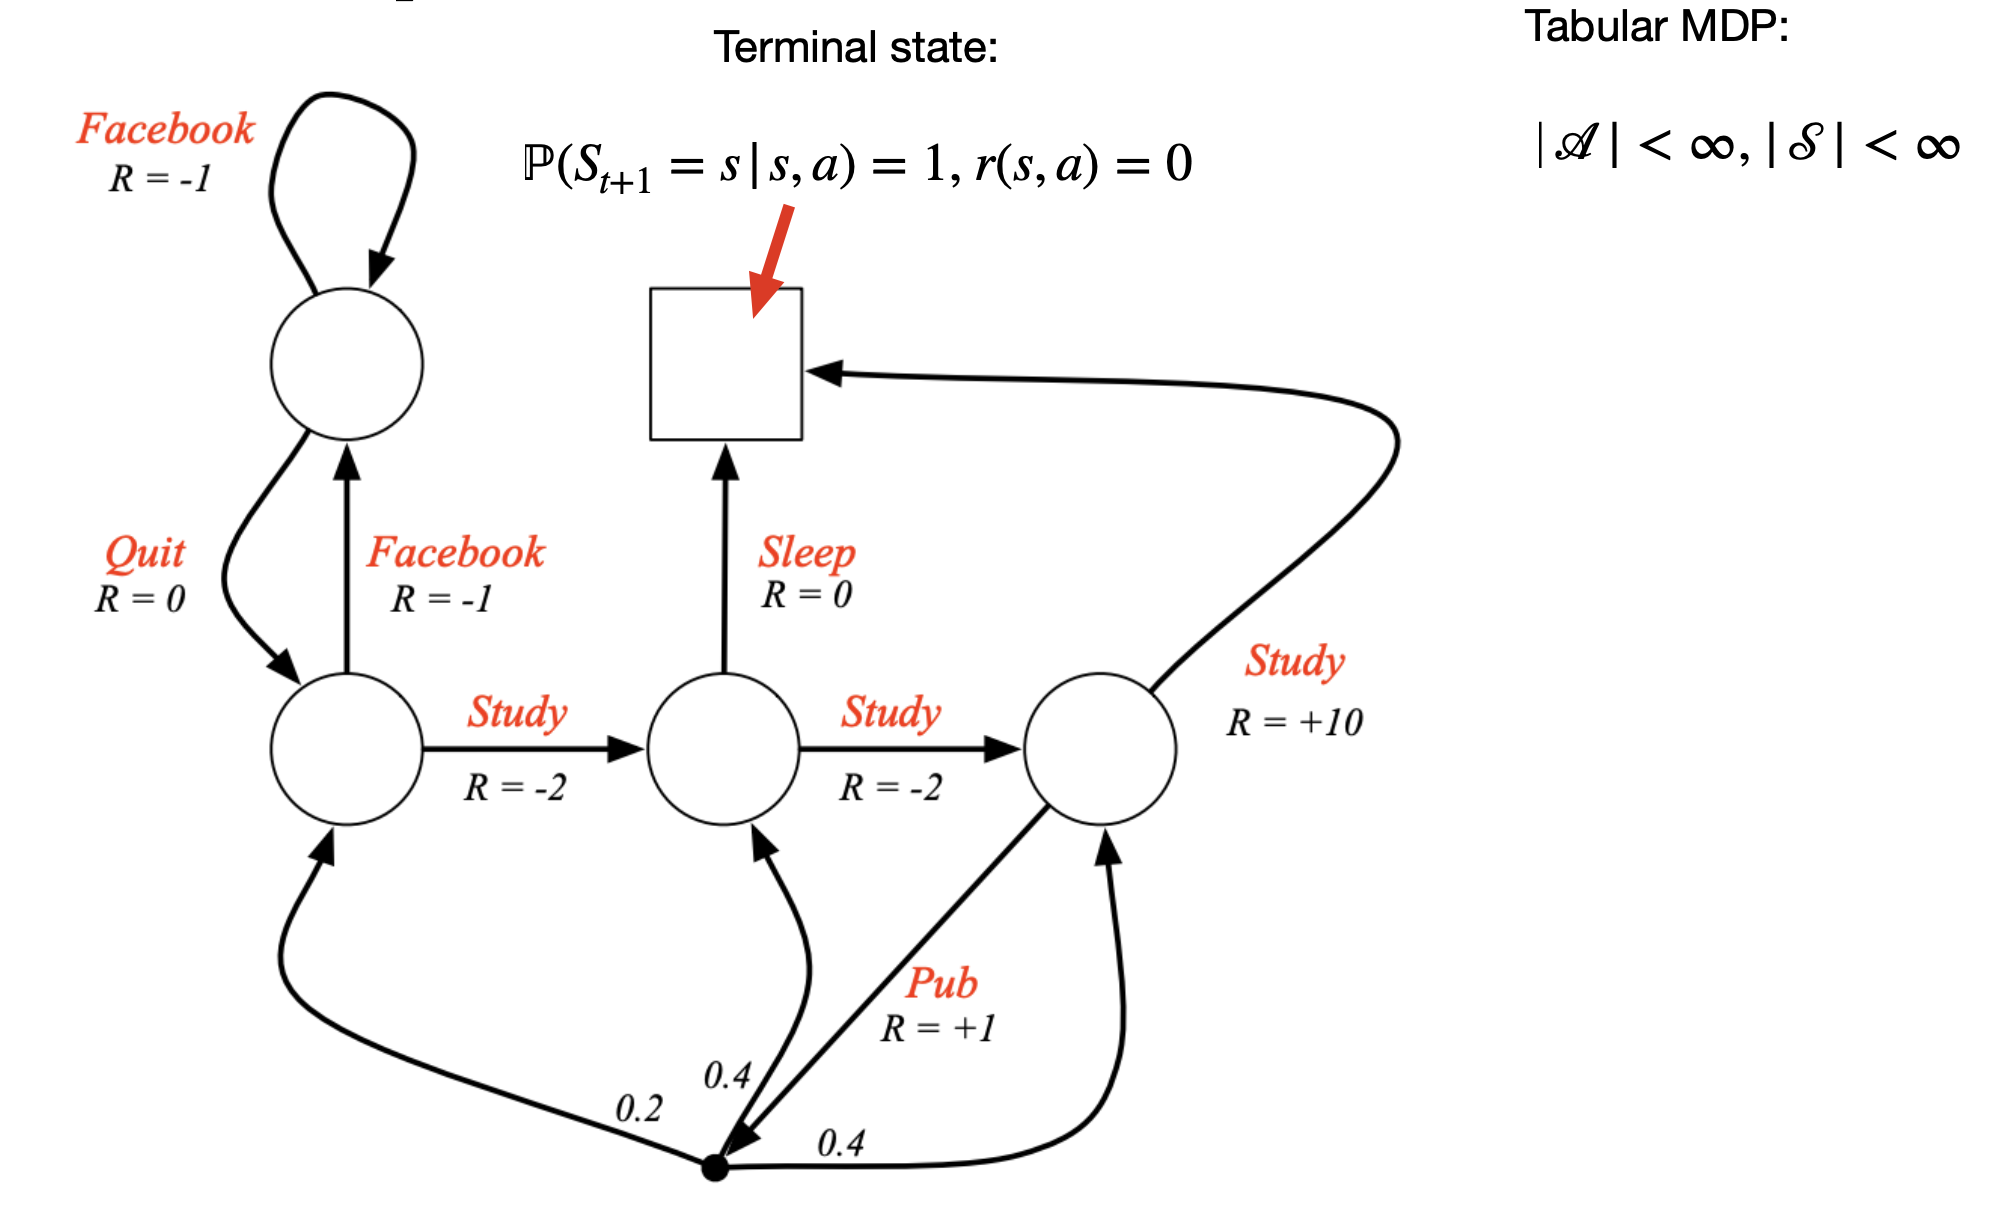

### Terminal state
**Терминальное состояние** — это такое состояние среды, из которого **агент больше не может выйти** и **не получает наград**:

$
\mathbb{P}(S_{t+1} = s \mid s, a) = 1, \quad r(s, a) = 0
$

**Проще говоря:**
- Если агент попал в это состояние — **эпизод закончен**.
- Это как в шахматах: **мат**, и больше ходов нет.
- Или как в жизни студента: **"Quit"** — всё, он больше не учится и не получает ни пользы, ни штрафа.

На слайде это прямоугольник (а не кружок) — визуально выделено, что туда ведёт только вход, но **не выход**.


### Tabular MDP

**Tabular MDP** — это частный случай MDP, где:

- **Конечное число состояний**: $ |\mathcal{S}| < \infty $
- **Конечное число действий**: $ |\mathcal{A}| < \infty $

**Что это значит?**
- Мы можем **записать все состояния и действия в таблицу**.
- Переходы и награды можно **явно задать матрицами или словарями**.

Примеры:
- Матрица переходов:  
  $P(s',r \mid s,a)$ — для каждого $s,a$ набор вероятностей по всем $s',r$
- Таблица значений (value function):  
  $V(s)$, $Q(s,a)$

# Returns and Episodes

Коментарий: В общщем случае, награды стохастические и состояния в которые можно перейти - стохастические - это некоторый случайный процесс.

Ещё одно замечание: Мы получаем награду за текущее состояние и действие и не учитываем прошлое ($R_{t-1}, R_{t_2}...$). И этот комулятивный ревард учитывает награду за текущее действие, сотояние и за все последующие.

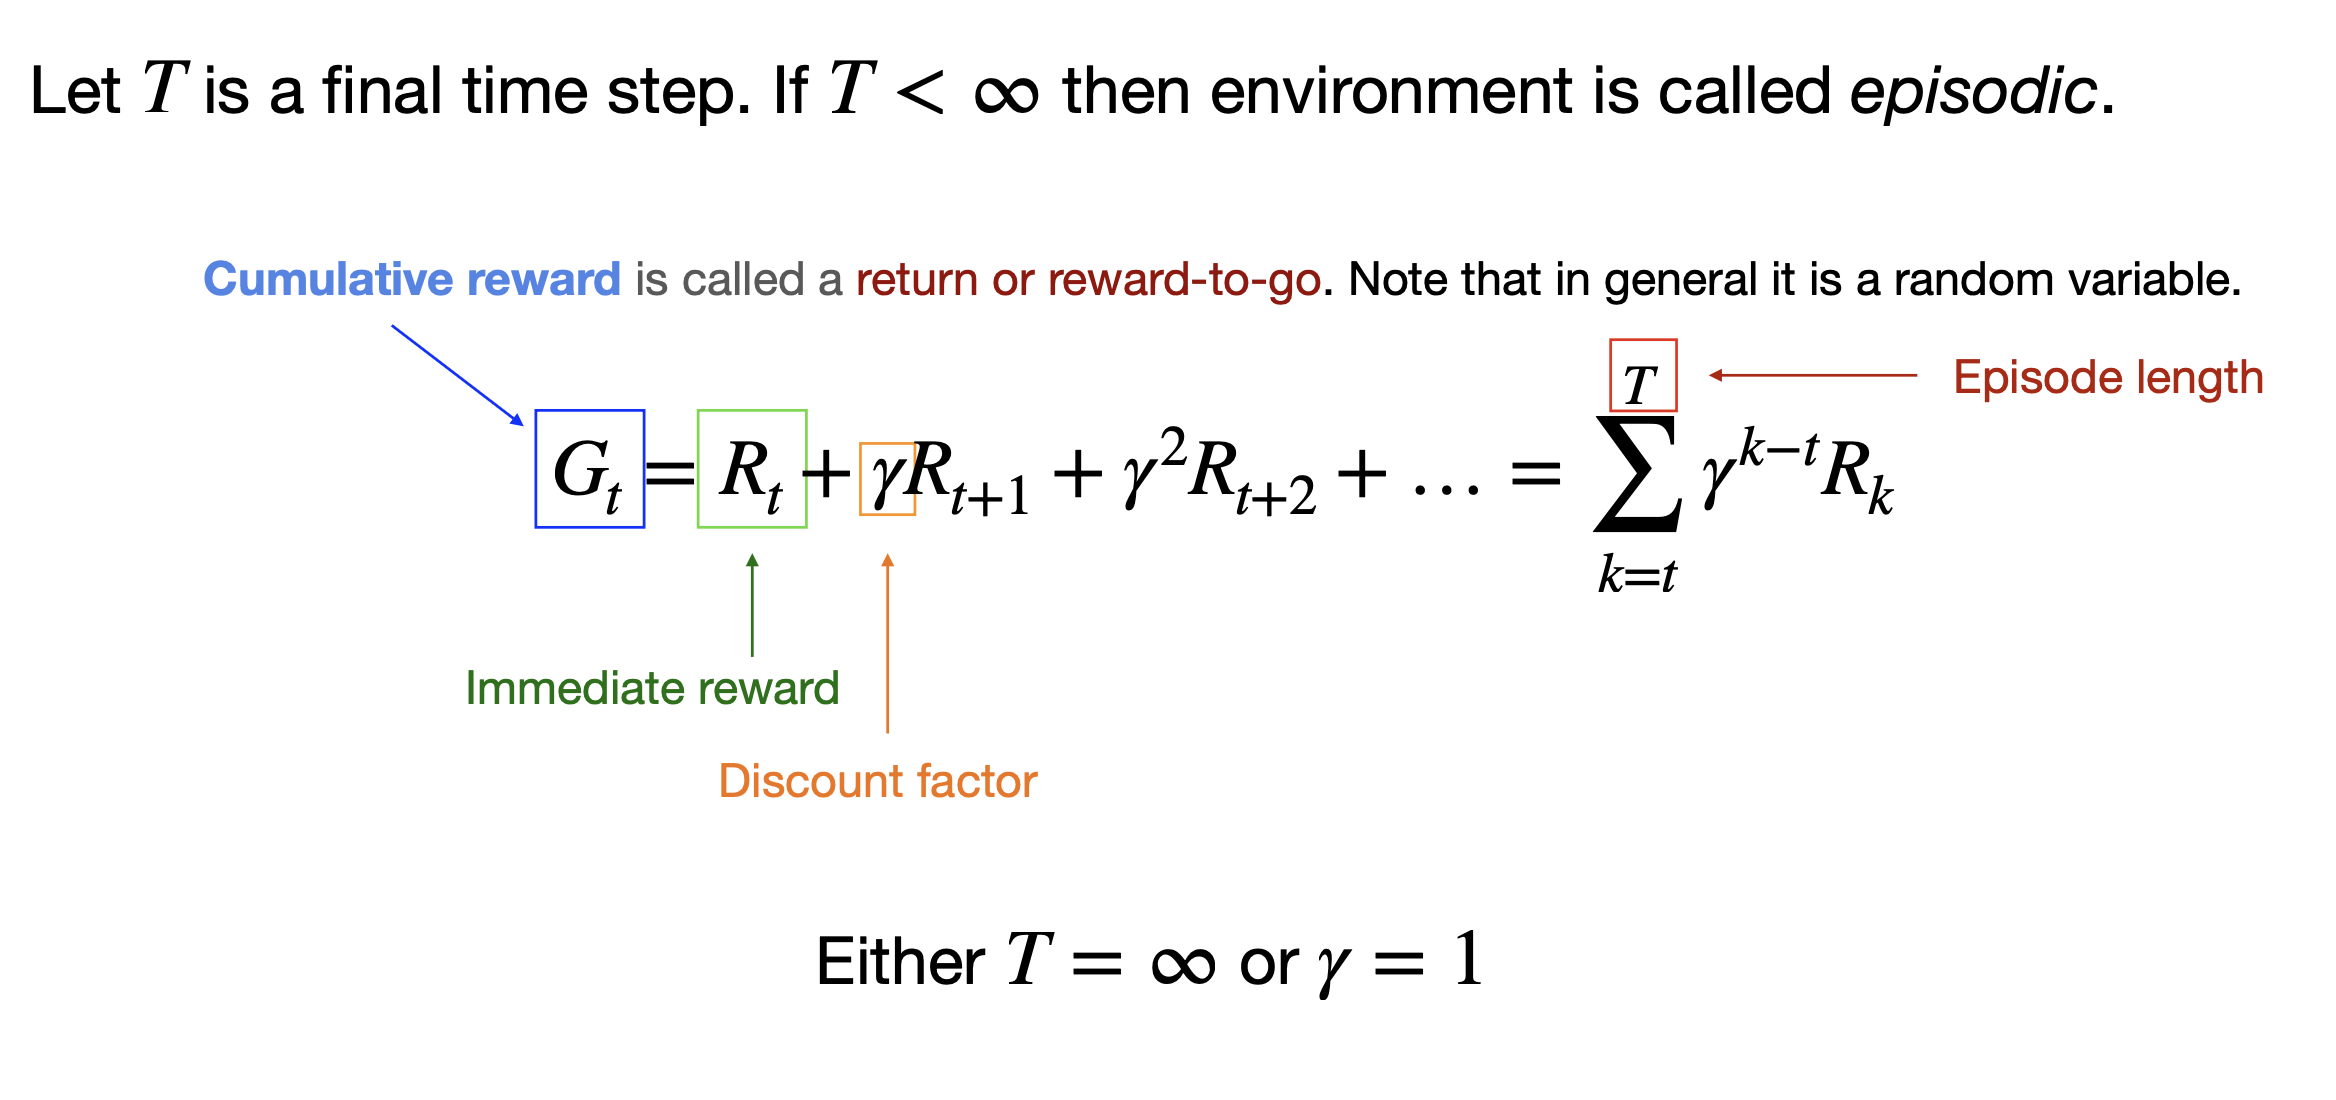

#### **Cumulative reward**:

Возврат $G_t$ можно выразить рекурсивно: **награда сейчас + дисконтированный возврат в будущем**.

$$\Huge
G_t = R_t + \gamma (R_{t+1} + \gamma R_{t+2} + \dots) = R_t + \gamma G_{t+1}
$$



# Objective Function

- **Agent interacts with the environment following some policy** $ \pi(a \mid s) $
- **Policy stochasticity**: $ a \sim \pi(\cdot \mid s) $  
- **Environment stochasticity**: $ s' \sim p(\cdot \mid s, a) $  
- **A trajectory**:  $\tau = (s_0, a_0, s_1, \dots, s_{T-1}, a_{T-1}, s_T)$
    - Так как, мы предпологаем, что награда детерминированная, поэтмоу мы не добавляем награду в траекторию. Следовательно, можно выписать кажду наградку как $r(s_0, a_0)$. Если награда стохастическая, то в траекторию необходимо добавить ещё награду, которую мы получили.

### Пояснение к обозначениям
Если у нас: $
\pi(a \mid s) = \text{вероятность выбрать действие } a \text{ в состоянии } s
$

То: $
\pi(\cdot \mid s)
$ — это **всё распределение по всем возможным действиям в состоянии $ s $**.

Тогда: $ a \sim \pi(\cdot \mid s) $ — **Сэмплируем действие** из распределения по $ \pi $ при фиксированном $ s $ 

<br>

$\Huge
J(\pi) = \mathbb{E}_\pi [G_0] = \mathbb{E}_{p(\tau \mid \pi)} [G_0] =
$

- $\mathbb{E}_\pi [G_0]$ Считаем коммулятивную награду начиная с 0 шага за все возможные взаимодействия с нашей средой, которые будет дальше.

$\Huge
= \mathbb{E}_{s_0 \sim p_0} \left[ \mathbb{E}_{a_0 \sim \pi(\cdot \mid s_0)} \left[ \mathbb{E}_{s_1 \sim p(\cdot \mid s_0, a_0)} \left[ r_0 + \gamma [\dots] \right] \right] \right] =
$

$\Huge
= \mathbb{E}_{s_0} \left[ \mathbb{E}_{a_0} \left[ \mathbb{E}_{s_1} \left[ r_0 + \gamma [\dots] \right] \right] \right] \rightarrow \max\limits_\pi
$

# State-value Function
Estimate how good it is for an agent to be in a given state $ s $ and follow a policy $ \pi $:

$$\Huge
V^\pi(s) = \mathbb{E}_\pi [G_t \mid S_t = s] = \mathbb{E}_\pi \left[ \sum_{k=0}^{T} \gamma^k R_{t+k} \mid S_t = s \right]
$$

If $ s $ is a terminal state then $ V^\pi(s) = 0 $.

### Вопрос про зависимость $ V^\pi(s) $ от времени

Если среда стационарна (то есть вероятности переходов не зависят от времени), а политика также стационарна (не меняется со временем), то функция ценности $ V^\pi(s) $ не зависит от времени. Иными словами, ожидаемое суммарное вознаграждение при старте из состояния $ s $ всегда одно и то же, независимо от того, на каком шаге времени мы начинаем.


### **Формально:**

Если среда **стационарна**:

$
p(s_{t+1} \mid s_t, a_t) = p(s' \mid s, a), \quad \forall t,
$

и политика **стационарна**:

$
\pi(a_t \mid s_t) = \pi(a \mid s), \quad \forall t,
$

то **функция ценности** $ V^\pi(s) $ не зависит от времени **при бесконечном горизонте** (или при $ T \to \infty $) и определяется как:

$
V^\pi(s) := \mathbb{E}_\pi \left[ \sum_{k=0}^{\infty} \gamma^k R_{t+k} \mid S_t = s \right] = \mathbb{E}_\pi \left[ \sum_{k=0}^{\infty} \gamma^k R_k \mid S_0 = s \right],
$

где $ \gamma \in [0, 1) $ — коэффициент дисконтирования. 

### Пояснение:
1. **Условие бесконечного горизонта** необходимо, чтобы временной сдвиг $ t $ не влиял на количество оставшихся шагов. При конечном $ T $ функция ценности зависела бы от $ t $, так как сумма наград обрезалась бы на $ T - t $.

2. **Стационарность среды и политики** гарантирует, что распределения переходов и наград одинаковы для всех $ t $. Это позволяет «сдвинуть» время и записать ожидаемую сумму наград как для $ t = 0 $, так и для любого $ t $.

3. **Дисконт $ \gamma $** обеспечивает сходимость ряда при $ \gamma < 1 $. Для $ \gamma = 1 $ ряд может расходиться, если награды не затухают.

### Итог:
Утверждение корректно **только для бесконечного горизонта с дисконтом** ($ T \to \infty, \, \gamma < 1 $). Ключевая ошибка в исходной формулировке — использование конечного $ T $, которое нарушает независимость от времени.

### **State-value Function**

$\Huge
V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s] = \mathbb{E}_\pi[R_t + \gamma G_{t+1} \mid S_t = s] 
\quad \text{⟵ Law of iterated expectation}
$

Запись в без Марковости:

$\Huge
= \sum\limits_a \pi(a \mid s) \sum\limits_{s'} 
\mathbb{P}(S_{t+1} = s' \mid S_t = s, A_t = a, S_{t-1} = s'', A_{t-1} = a'', \dots) 
\left[r + \gamma \mathbb{E}_\pi[G_{t+1} \mid S_{t+1} = s'] \right] 
$

<br>
Применяем Марковское свойство (у нас Марковская среда), тогда выражение станет проще. Так же, стационарность состояния тоже играет роль, благо чему нет зависимости от времени.

$\Huge
\text{Markov property ⟶} \quad 
= \sum\limits_a 
\underbrace{\pi(a \mid s)}_{\text{Policy stochasticity}} 
\sum\limits_{s'} 
\underbrace{\mathbb{P}(S_{t+1} = s' \mid S_t = s, A_t = a)}_{\text{Definition of state transition function}} 
\left[r + \gamma \mathbb{E}_\pi[G_{t+1} \mid S_{t+1} = s'] \right]
$


$\Huge
= \sum\limits_a \pi(a \mid s) \sum\limits_{s'} 
p(s' \mid s, a) 
\left[r + \gamma 
\underbrace{\mathbb{E}_\pi[G_{t+1} \mid S_{t+1} = s']}_{\text{Definition of } V^\pi(s')}
\right]
$

* $\underbrace{\mathbb{E}_\pi[G_{t+1} \mid S_{t+1} = s']}_{\text{Definition of } V^\pi(s')}$ - Получили $V^\pi(s')$, но как будто мы начинаем из следующего состояния. Дальше эту конструкцию заменим на $V^\pi(s')$. Здесь мы получили Уравнение Беллмана. Мы выразили награду в текущем состоянии, через награду, которую мы получим за текущее взаимодействие и ожидаему награду в тех состояних, в которые мы можем придти - поэтому тут мат ожидание, но если среда детерменированная и политика детерменированная, тогда эти мат ожидания пропадут (будет конерктно действие и конкретное состояние). И в этом случа будет $V^\pi(s) = r(s, \pi(s)) + \gamma V^\pi(s')$ 

<br>

$\Huge
= \sum\limits_a 
\underbrace{\pi(a \mid s)}_{\text{Policy stochasticity}} 
\sum\limits_{s'} 
\underbrace{p(s' \mid s, a)}_{\text{Environment stochasticity}} 
\left[r + \gamma V^\pi(s') \right]
= \mathbb{E}_a \left[ r(s, a) + \gamma \mathbb{E}_{s'} V^\pi(s') \right]
$

https://chatgpt.com/c/680aa0d8-b214-8006-8fb3-085545218e30

https://chatgpt.com/c/68080323-64cc-8006-bc5b-c3d251a5a40a

# **Action-value Function**

Estimate how good it is for the agent to take an action $ a $ being in a given state $ s $ and follow a policy $ \pi $:

$\Huge
Q^\pi(s, a) = \mathbb{E}_\pi \left[ G_t \mid S_t = s, A_t = a \right] = \mathbb{E}_\pi \left[ \sum\limits_{k=0}^{T} \gamma^k R_{t+k} \,\middle|\, S_t = s, A_t = a \right]
$

If $ s $ is a terminal state then  
$
Q^\pi(s, a) = 0 \quad \forall a \in \mathcal{A}.
$


### Что такое $ Q^\pi(s, a) $?

Это **ожидаемое общее вознаграждение**, которое агент получит, **начиная из состояния $s$**, **выполнив действие $a$**, и **затем следуя политике $ \pi $**.

### Переписанная формула уравнения Беллмана для $ Q^\pi(s, a) $:


$\Large
Q^\pi(s, a) = \mathbb{E}_\pi \left[ G_t \mid S_t = s, A_t = a \right] = \mathbb{E}_\pi \left[ R_t + \gamma G_{t+1} \mid S_t = s, A_t = a \right]
$

$\Large
= \sum_{s'} p(s' \mid s, a) \left[ r + \gamma \mathbb{E}_\pi \left[ G_{t+1} \mid S_{t+1} = s' \right] \right]
= \sum_{s'} p(s' \mid s, a) \left[ r + \gamma V^\pi(s') \right]
$

$\Large
= r(s, a) + \gamma \mathbb{E}_{s'} V^\pi(s')
$


В целом, повторили всё то, что делали для $V^\pi(s)$. В конце пропало мат ожидание по действием, которое было у $V^\pi(s)$, так как мы тут выбрали конкретное действие. 

# **`Bellman Equations`**
# **"Relationship between $ V^\pi $ and $ Q^\pi $"**:

Это как раз следуюет из прошлых выкладок и называется "Уравнение Беллмана"

$
\Large
V^\pi(s) = \sum\limits_a \pi(a \mid s) 
\underbrace{\sum\limits_{s'} p(s' \mid s, a) \left[ r + \gamma V^\pi(s') \right]}_{\color{blue}{Q^\pi(s, a)}}
$

$
\Large
Q^\pi(s, a) = \color{blue}{\sum\limits_{s'} p(s' \mid s, a) \left[ r + \gamma V^\pi(s') \right]}
$

Синим мы подсветили, одно и то же. Следовательно, есть связь между $ V^\pi $ and $ Q^\pi $" функциями. Значит, $V^\pi(s)$ можно записать как:


$\Large
V^\pi(s) = \sum\limits_a \pi(a \mid s) Q^\pi(s, a) = \mathbb{E}_{a \sim \pi(\cdot \mid s)} Q^\pi(s, a)
$

Теперь, выржание которое мы только что поулчили, можем подставить в $Q^\pi(s, a)$ заместо $V^\pi(s)$:

$\Large
Q^\pi(s, a) = \sum\limits_{s'} p(s' \mid s, a) \left[ r + \gamma \sum\limits_{a'} \pi(a' \mid s') Q^\pi(s', a') \right]
$

Что мы хотим? Мы хотим понять как соотносятся между собой $ V^\pi $ and $ Q^\pi $". И можно ли выразить $ V^\pi(s) $ через $ V^\pi(s') $ аналогично и с $Q^\pi(s, a)$. Как оказалось можно. И вот что мы получаем:

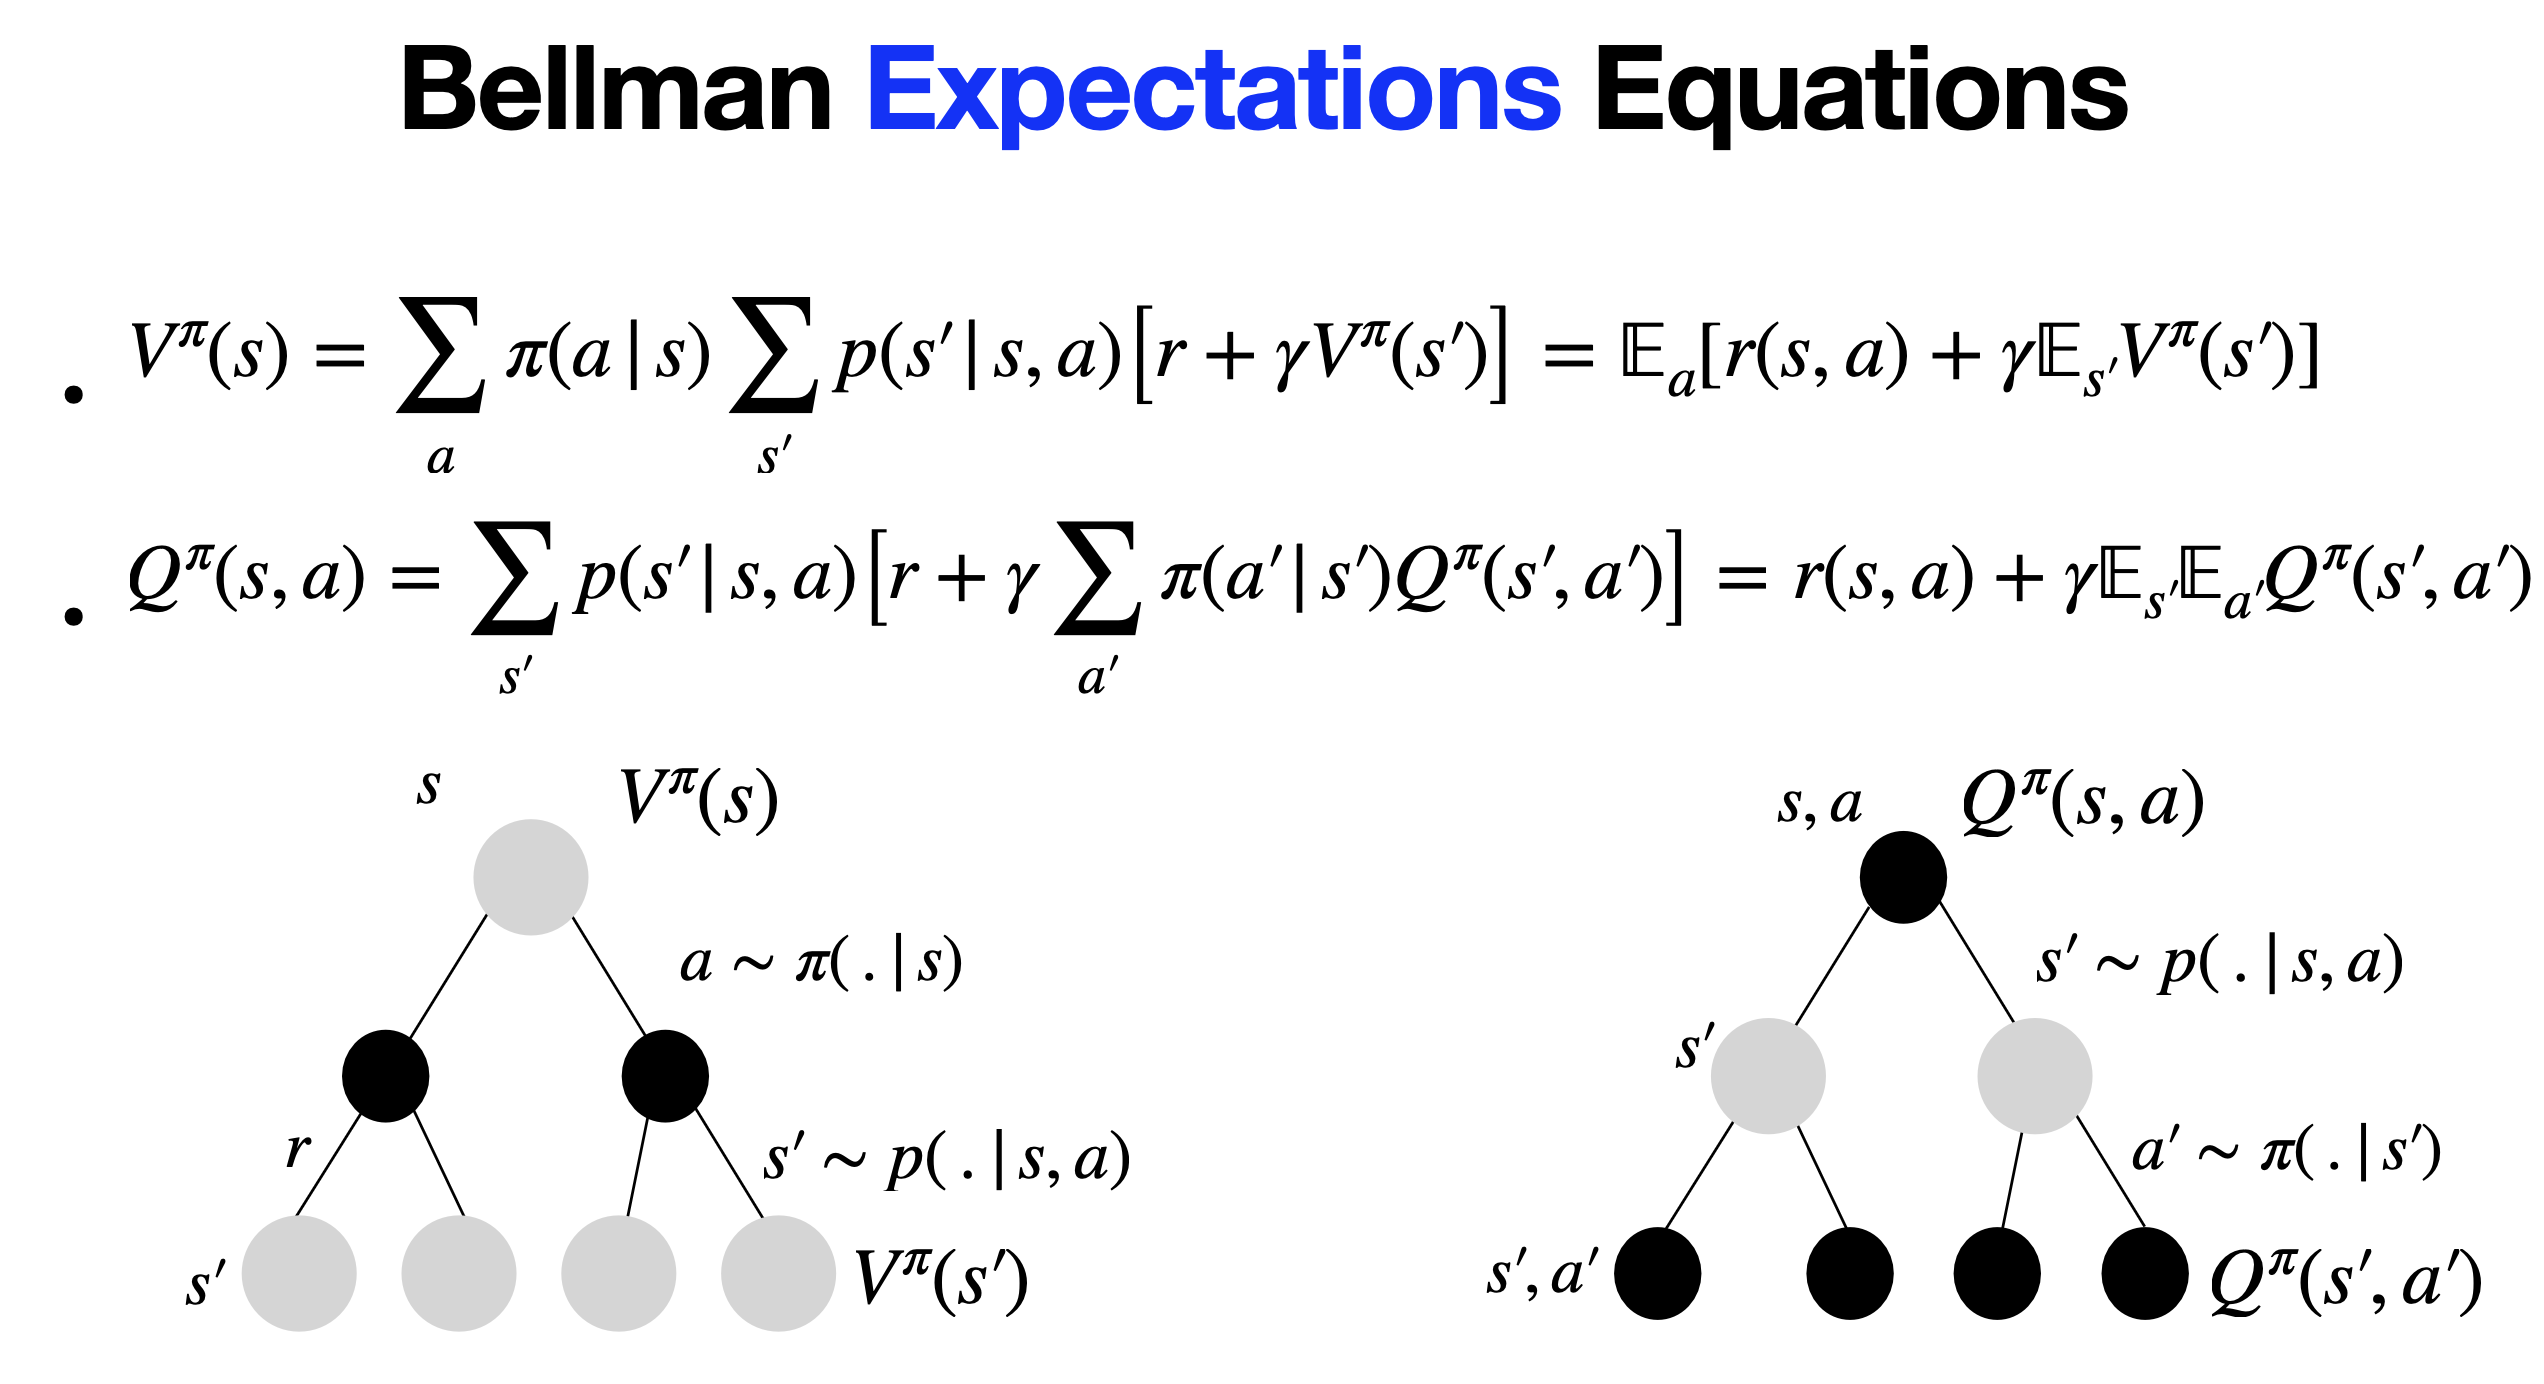

https://www.mdpi.com/entropy/entropy-23-00274/article_deploy/html/images/entropy-23-00274-g002.png
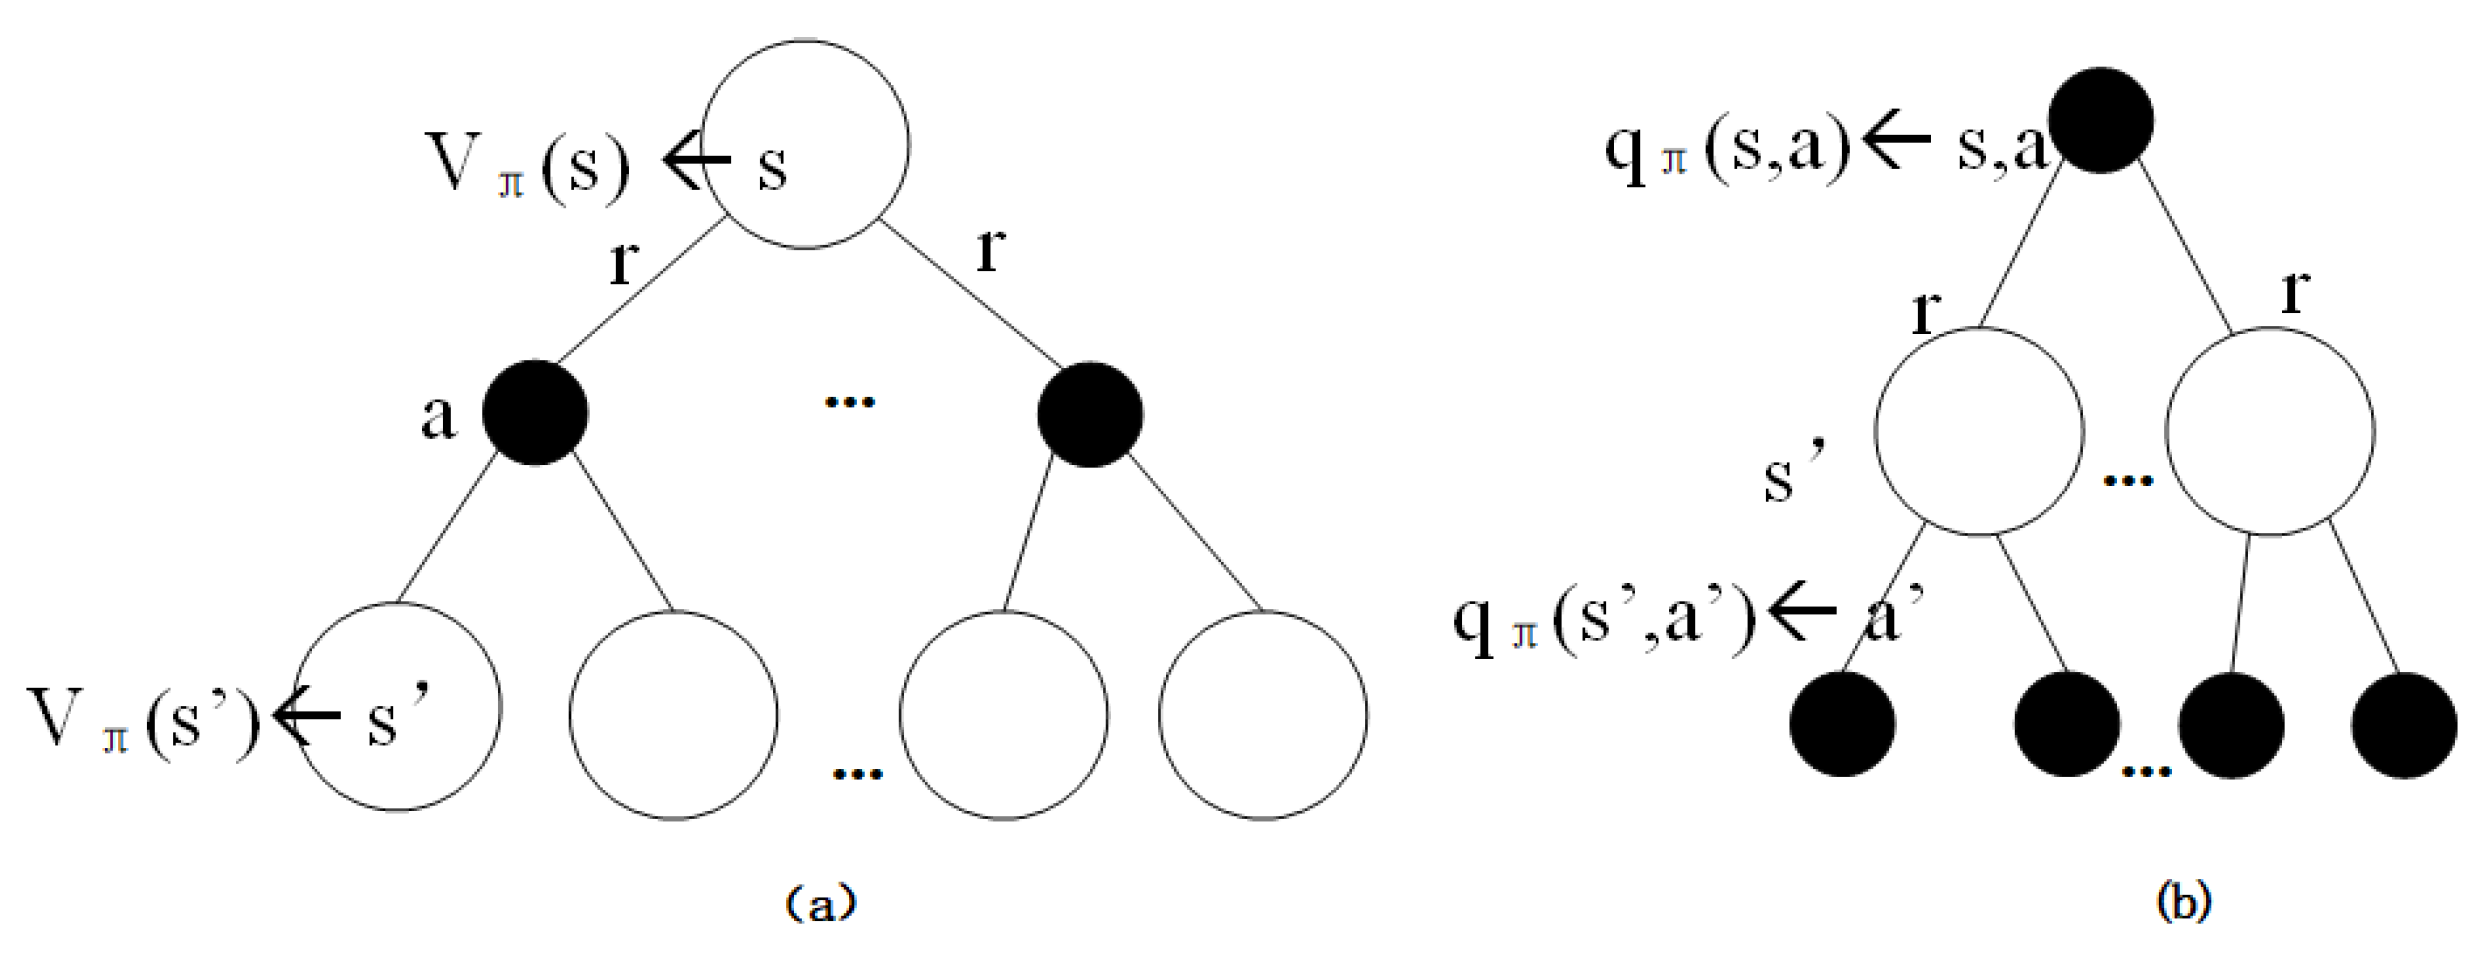

### Поиск лучшего пути применением Динамического программирвоания

Карта наград:
 [[7 4 8 5 7 3 7 8 5 4]
 [8 8 3 6 5 2 8 6 2 5]
 [1 6 9 1 3 7 4 9 3 5]
 [3 7 5 9 7 2 4 9 2 9]
 [5 2 4 7 8 3 1 4 2 8]
 [4 2 6 6 4 6 2 2 4 8]
 [7 9 8 5 2 5 8 9 9 1]
 [9 7 9 8 1 8 8 3 1 8]
 [3 3 1 5 7 9 7 9 8 2]
 [1 7 7 8 5 3 8 6 3 1]]
Оптимальный путь: [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (3, 2), (4, 2), (5, 2), (6, 2), (7, 2), (7, 3), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8), (9, 8), (9, 9)]


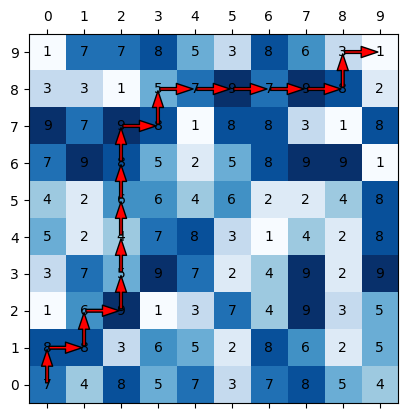

In [35]:
import numpy as np
import matplotlib.pyplot as plt


def generate_map(rows, cols, min_reward=1, max_reward=9):
    return np.random.randint(min_reward, max_reward+1, size=(rows, cols))


def bellman_optimal_path(reward_map):
    rows, cols = reward_map.shape
    V = np.zeros((rows, cols), dtype=int)

    for i in reversed(range(rows)):
        for j in reversed(range(cols)):
            moves = []
            if i+1 < rows:
                moves.append(V[i+1, j])  # вниз
            if j+1 < cols:
                moves.append(V[i, j+1])  # вправо
            if i+1 < rows and j+1 < cols:
                moves.append(1 * V[i+1, j+1])  # диагональ усиливается в 4 раза

            V[i, j] = reward_map[i, j] + (max(moves) if moves else 0)

    # восстановление пути
    path = [(0, 0)]
    i = j = 0
    while (i < rows - 1) or (j < cols - 1):
        moves = {}
        if i+1 < rows:
            moves[(i+1, j)] = V[i+1, j]
        if j+1 < cols:
            moves[(i, j+1)] = V[i, j+1]
        if i+1 < rows and j+1 < cols:
            moves[(i+1, j+1)] = 1 * V[i+1, j+1]  # также учитываем усиление при восстановлении пути

        next_move = max(moves, key=moves.get)
        path.append(next_move)
        i, j = next_move

    return V, path


def plot_map(reward_map, path):
    rows, cols = reward_map.shape
    fig, ax = plt.subplots()
    ax.matshow(reward_map, cmap='Blues')

    for i in range(rows):
        for j in range(cols):
            ax.text(j, i, f'{reward_map[i,j]}', ha='center', va='center', color='black')

    # Рисуем стрелки пути
    for (i1, j1), (i2, j2) in zip(path[:-1], path[1:]):
        ax.annotate('', xy=(j2, i2), xytext=(j1, i1),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8))

    plt.xticks(range(cols))
    plt.yticks(range(rows))
    plt.gca().invert_yaxis()
    plt.show()

np.random.seed(42)
reward_map = generate_map(10, 10)
reward_map
V, optimal_path = bellman_optimal_path(reward_map)

print("Карта наград:\n", reward_map)
print("Оптимальный путь:", optimal_path)

plot_map(reward_map, optimal_path)

### Рекурсивная реализация

In [40]:
np.random.seed(42)
rewards = generate_map(10, 10)
rows, cols = len(rewards), len(rewards[0])

@lru_cache(maxsize=None)
def V(i, j):
    if i >= rows or j >= cols:
        return float('-inf')
    if i == rows - 1 and j == cols - 1:
        return rewards[i][j]
    right = V(i, j + 1)
    down = V(i + 1, j)
    diag = V(i + 1, j + 1)

    # Формула Беллмана с γ=1
    return rewards[i][j] + max(right, down, diag)

optimal_value = V(0, 0)
print(f"Оптимальное значение пути: {optimal_value}")

Оптимальное значение пути: 127


### Рекурсивная реализация с выводом оптимальной траектории

In [37]:
from functools import lru_cache

np.random.seed(42)
rewards = generate_map(10, 10)

rows, cols = len(rewards), len(rewards[0])

@lru_cache(maxsize=None)
def V(i, j):
    if i >= rows or j >= cols:
        return (float('-inf'), ())
    if i == rows - 1 and j == cols - 1:
        return (rewards[i][j], ((i, j),))
        
    # Рекурсивно получаем значения и пути для всех возможных направлений
    right_val, right_path = V(i, j + 1)
    down_val, down_path = V(i + 1, j)
    diag_val, diag_path = V(i + 1, j + 1)
    # Выбираем направление с максимальной наградой
    max_val = max(right_val, down_val, diag_val)
    # Формируем путь в зависимости от выбранного направления
    if max_val == right_val:
        best_path = ((i, j),) + right_path
    elif max_val == down_val:
        best_path = ((i, j),) + down_path
    else:
        best_path = ((i, j),) + diag_path
    # Вычисляем текущее значение с учётом награды
    current_value = rewards[i][j] + max_val
    return (current_value, best_path)

# Получаем оптимальное значение и путь
value, path = V(0, 0)

print(f"Оптимальное значение пути: {value}")
print("Оптимальный путь:", " -> ".join(f"({i},{j})" for (i, j) in path))

Оптимальное значение пути: 127
Оптимальный путь: (0,0) -> (1,0) -> (1,1) -> (2,1) -> (2,2) -> (3,2) -> (3,3) -> (3,4) -> (4,4) -> (5,4) -> (5,5) -> (6,5) -> (7,5) -> (8,5) -> (8,6) -> (8,7) -> (8,8) -> (9,8) -> (9,9)


# **Optimal Value Function**

Recall that our goal is to find a policy that achieves maximum expected cumulative discounted reward.

Define optimal value functions:

$\large
V^*(s) = \max\limits_\pi V^\pi(s)
$ - получим оценку, насколько наша политика хороша, при условии, что она оптимальна.

$\large
Q^*(s, a) = \max\limits_\pi Q^\pi(s, a)
$ - аналогично.

- The optimal value function specifies the best possible performance in the MDP.  
- An MDP is “solved” when we know the optimal value function.

### Или $V^*(s)$ можно записать как:

> Не во всех случаях максимизация одного, даст один и тот же ответ, максимизируя другое.


$\large
J(\pi) = \mathbb{E} \left[ V^\pi(s_0) \right], \quad s_0 \sim p_0 \quad \Rightarrow \max\limits_\pi
$

Это означает: Мы хотим **максимизировать ожидаемую ценность начального состояния** $ s_0 $, где $ s_0 $ берётся из начального распределения $ p_0 $. Цель — найти такую политику $ \pi $, которая даст **максимальный стартовый возврат**.


### Что мы сравниваем:

1. **Оптимальная ценность конкретного состояния**:
$
V^*(s) = \max_\pi V^\pi(s)
$
→ Максимально возможная награда, если **стартуем из заданного состояния $s$** и действуем по **лучшей политике**.

2. **Ожидаемая ценность начального распределения**:
$
J(\pi) = \mathbb{E}_{s_0 \sim p_0}[V^\pi(s_0)] \Rightarrow \max\limits_\pi
$
→ Средняя награда, которую получим, если **стартовать из случайного состояния $s_0$** (согласно $ p_0 $), и действовать по политике $ \pi $.


# **Optimal Policy**

Define a partial order on a set of possible policies:

$\large
\pi \geq \pi' \iff V^\pi(s) \geq V^{\pi'}(s)\quad \forall s \in \mathcal{S}
$

**Theorem: For any MDP**

- There exists an optimal policy $ \pi^* $ that is better than or equal to all other policies,  
  $\large \pi^* \geq \pi \;\; \forall \pi $
  
- All optimal policies achieve the optimal value functions

### **Finding an Optimal Policy**

- An optimal policy can be found:  
  $\large
  \pi^*(a \mid s) = \mathbb{I}\left[a = \arg\max\limits_{a'} Q^*(s, a')\right]
  $

- There is always a deterministic optimal policy for any MDP 


Если у вас есть Q-звездой, то вы можете просто промаксимизировать по действиям. То есть, по сути, всю вероятностную массу положить в конкретное-то действие.

«Положить всю вероятностную массу в конкретное действие» = «сделать политику детерминированной: вероятность 1 на действии-аргмакс, 0 на остальных». Это обеспечивает оптимальность, потому что мы всегда выбираем действие с наибольшей ценностью $Q^*$. Утверждается что для MDP существует оптимальная детерменированная политика (находится по правилу, которые записали первым пунктом выше):

> - There is always a deterministic optimal policy for any MDP. 

> **Оптимальная политика $\pi^*$ не обязательно единственна.** То есть может существовать **несколько стратегий**, которые приводят **к одному и тому же оптимальному результату**.

### Почему так?

Представим: В некотором состоянии $ s $, два действия $ a_1 $ и $ a_2 $ дают одинаковую ожидаемую награду:

$
Q^*(s, a_1) = Q^*(s, a_2)
$

Тогда:

- Можно выбрать $ a_1 $ всегда — будет оптимально
- Можно выбрать $ a_2 $ всегда — тоже оптимально
- Можно выбирать случайно, например, $ \pi(a_1 \mid s) = 0.5 $, $ \pi(a_2 \mid s) = 0.5 $ — всё ещё оптимально

> То есть **все эти стратегии равнозначны с точки зрения функции ценности $ V^*(s) $**.

### Как это связано с формальным определением?

На предыдущем слайде было:

$
\pi^*(a \mid s) = \mathbb{I}[a = \arg\max\limits_{a'} Q^*(s, a')]
$

Но если $ \arg\max $ не единственный (несколько $ a' $ дают один и тот же максимум), то вы **можете выбрать любую смесь** между ними.

### Практический смысл:

- **Оптимальная политика может быть стохастической**, даже если есть детерминированная
- **Все такие политики равны по качеству**:  
  $ \pi_1^*, \pi_2^* \Rightarrow V^{\pi_1^*}(s) = V^{\pi_2^*}(s) = V^*(s) $
- Это важно в задачах, где **рандомизация может быть полезной** (например, при наличии симметрий, непредсказуемости и т.д.)

# **Bellman Optimality Equations**


Мы уже выписывали уравнение Bellman для Expectations, осталось выписать уравнение Bellman для Optimality. Для этого запишем $V^*(s)$ как $\mathbb{E}_{a \sim \pi^*} Q^{\pi^*}(s, a)$. Мы уже записывали данное выражение в "Relationship between $ V^\pi $ and $ Q^\pi $" и оно имело следующий вид: 


$V^{\pi}(s) = \mathbb{E}_{a \sim \pi(\cdot \mid s)} \left[ Q^{\pi}(s, a) \right]$


Поскольку $\pi^*(a \mid s) = \mathbb{I}[a = \arg\max\limits_{a'} Q^*(s, a')]$, и так как политика детерминирована (следует из теории выше), тогда $V^*(s) = \max\limits_a Q^*(s, a)$:

$$\large
V^*(s) = \mathbb{E}_{a \sim \pi^*} Q^{\pi^*}(s, a) \quad \Longrightarrow \quad V^*(s) = \max\limits_a Q^*(s, a)
$$

<br>
Далее повторяем то, что делалаи раннее с точки зрения мат выкладок:

$\large
\boxed{V^*(s)} = \max\limits_a \, \mathbb{E}_{\pi^*} [G_t \mid S_t = s, A_t = a] 
= \max\limits_a \, \mathbb{E}_{\pi^*} [R_t + \gamma G_{t+1} \mid S_t = s, A_t = a]
$

$\large
= \max\limits_a \, \mathbb{E}_{\pi^*} \left[ R_t + \gamma V^*(S_{t+1}) \mid S_t = s, A_t = a \right] 
= \max\limits_a \sum\limits_{s'} p(s' \mid s, a) \left[ r + \gamma V^*(s') \right]
$

$$\large
= \max_a \left[ r(s, a) + \gamma \, \mathbb{E}_{s'} \boxed{V^*(s')} \right]
$$


- $ \boxed{V^*(s)} $ — оптимальная ценность состояния.
- $ \boxed{V^*(s')} $ — оптимальная ценность следующего состояния после перехода.

---
Это выражение:
$V^*(s)$ как $\mathbb{E}_{a \sim \pi^*} Q^{\pi^*}(s, a)$

мы записали через это выражение:
$V^{\pi}(s) = \mathbb{E}_{a \sim \pi(\cdot \mid s)} \left[ Q^{\pi}(s, a) \right]$

---


Да, всё верно — первое равенство просто **частный случай** общего тождества, когда в него подставили оптимальную политику $\pi^*$.

### 1. Общее тождество (для любой политики)

$
\boxed{V^{\pi}(s)=\mathbb E_{a\sim\pi(\cdot\mid s)}\bigl[\,Q^{\pi}(s,a)\bigr]}
\tag{1}
$

Получается напрямую из определения ожидания:  
$V^{\pi}(s)=\sum_{a}\pi(a\mid s)Q^{\pi}(s,a)$.


### 2. Подставляем $\pi=\pi^*$

Берём ту же формулу (1) и вместо $\pi$ пишем $\pi^*$:

$
V^{\pi^*}(s)=\mathbb E_{a\sim\pi^*(\cdot\mid s)}\bigl[\,Q^{\pi^*}(s,a)\bigr].
$

Поскольку $V^{\pi^*}=V^*$ и $Q^{\pi^*}=Q^*$, получаем

$
\boxed{V^*(s)=\mathbb E_{a\sim\pi^*} Q^{*}(s,a)}.
\tag{2}
$


### 3. Почему дальше «ожидание превращается в максимум»

Дополнительный шаг:

* $\pi^*$ детерминирована и выбирает действие-аргмакс:  
  $\pi^*(a\mid s)=\mathbf 1[a=\arg\max_{a'}Q^*(s,a')]$.
* Поэтому в сумме (или ожидании) остаётся ровно одно ненулевое слагаемое, и (2) упрощается до  

$
V^*(s)=\max_a Q^*(s,a).
$


Так что никаких противоречий:

* (1) — универсальное уравнение для **любой** политики.  
* (2) — тот же факт, но с $\pi=\pi^*$.  
* «Ожидание → максимум» — следствие того, что $\pi^*$ кладёт всю вероятность (массу = 1) на действие с максимальным $Q^*$.

### Шаг-за-шагом, почему  
$\large
V^*(s)=\mathbb E_{a\sim\pi^*}Q^*(s,a)\;=\;\max_{a}Q^*(s,a)
$

#### 1. Что такое $\pi^*(a\mid s)$

По определению оптимальной детерминированной политики  
$
\pi^*(a\mid s)=\mathbf 1\!\bigl[a=a_{\max}\bigr],
\qquad 
a_{\max}\;:=\;\arg\max_{a'}Q^*(s,a').
$

* Индикатор $\mathbf 1[\cdot]$ равен 1, если условие внутри истинно, иначе 0.  
* То есть **всё вероятностное “топливо” (масса = 1)** кладём на действие $a_{\max}$; другие получают 0.

> Если аргмаксов несколько (все они дают одинаковое $Q^*$), можно распределить массу как угодно **между ними** — результат не изменится, потому что у всех этих действий одна и та же величина $Q^*(s,a)=\max_a Q^*(s,a)$.

#### 2. Подставляем в определение ожидания

$
\mathbb E_{a\sim\pi^*}Q^*(s,a)
\;=\;
\sum_{a}\pi^*(a\mid s)\,Q^*(s,a).
$

Теперь используем тот факт, что $\pi^*(a\mid s)=0$ везде, кроме $a_{\max}$:

$
\sum_{a}\pi^*(a\mid s)\,Q^*(s,a)
=\underbrace{\pi^*(a_{\max}\!\mid s)}_{=1}\,Q^*(s,a_{\max})
+\sum_{a\neq a_{\max}}\underbrace{\pi^*(a\mid s)}_{=0}\,Q^*(s,a)
=Q^*(s,a_{\max}).
$


#### 3. Замечаем, что $Q^*(s,a_{\max})=\max_a Q^*(s,a)$

По определению $a_{\max}$ — действие, в котором $Q^*$ достигает своего максимального значения.

Следовательно  
$
Q^*(s,a_{\max})=\max_{a}Q^*(s,a),
$
а значит  

$
V^*(s)=\mathbb E_{a\sim\pi^*}Q^*(s,a)=\max_{a}Q^*(s,a).
$


### Интуитивно

* **Ожидание** по распределению, всё-таки состоящему из **одной точки с вероятностью 1**, просто возвращает значение в этой точке.  
* Если есть несколько равноценных максимумов, любая смесь из них всё равно даст это же максимальное значение, потому что каждая из компонент уже равна $\max Q^*$.

Вот и вся «магия» перехода: когда политика концентрируется на оптимальных действиях, среднее превращается в максимум.

## 1. Универсальная связь $V^\pi$ и $Q^\pi$

Для **любой** политики $ \pi $ выполняется

$
\boxed{V^{\pi}(s)=\mathbb E_{a\sim\pi(\cdot\mid s)}[\,Q^{\pi}(s,a)\,]}
\tag{1}
$

* **Что это значит?** – ценность состояния $s$ равна среднему (по той же политике) значению action-value.  
* **Как получить?** – просто раскрываем определение матожидания:  
  $V^\pi(s)=\sum_{a}\pi(a\mid s)Q^\pi(s,a)$.


## 2. Что происходит, если $ \pi $ **детерминирована**

Пусть политика выбирает **одно** действие $a_\pi(s)$ с вероятностью 1:

$
\pi(a\mid s)=
\begin{cases}
1,&a=a_\pi(s)\\
0,&a\neq a_\pi(s)
\end{cases}
$

Тогда ожидание в (1) схлопывается в одно слагаемое:

$
V^{\pi}(s)=Q^{\pi}\!\bigl(s,a_\pi(s)\bigr).
\tag{2}
$

То есть **«положили всю вероятностную массу в один action» ⇒ среднее = конкретное значение Q**.


## 3. Переход к оптимальности

Определяем оптимальную детерминированную политику

$
\pi^*(a\mid s)=\mathbf 1\!\Bigl[a=\!\arg\max_{a'}Q^*(s,a')\Bigr].
\tag{3}
$

* Она всегда выбирает действие(я) с максимальным $Q^*(s,a)$.  
* Подставляем (3) в формулу (1):

$
V^*(s)=\mathbb E_{a\sim\pi^*}Q^*(s,a)
      =\sum_{a}\pi^*(a\mid s)Q^*(s,a)
      =Q^*\!\bigl(s,a_{\max}\bigr)
      =\max_{a}Q^*(s,a).
\tag{4}
$

Последнее равенство держится, потому что $a_{\max}$ — это как раз аргмакс.

> **Ключевая мысль**: когда политика детерминирована и всегда берёт действие-аргмакс, «среднее по политике» превращается в **максимум**.


## 4. Итоговые связи

| формула | когда используется | комментарий |
|---------|-------------------|-------------|
| $V^{\pi}(s)=\sum_a\pi(a\mid s)Q^\pi(s,a)$ | любая политика | «value = среднее Q» |
| $V^{\pi}(s)=Q^{\pi}(s,a_\pi(s))$ | детерминированная $\pi$ | один action с массой 1 |
| $V^*(s)=\max_a Q^*(s,a)$ | оптимальная $\pi^*$ | действие выбрано из argmax, поэтому ожидание = максимум |

Таким образом:

* выражение (1) — фундаментальная связь между $V^\pi$ и $Q^\pi$;
* для детерминированной политики оно упрощается до одного $Q$;
* если политика ещё и **оптимальна**, этот единственный $Q$ совпадает с глобальным максимумом, поэтому возникает шаг «ожидание → максимум».

# **Bellman Optimality Equations**

Для $Q^\pi(s, a)$ повторяем то же самое:

$\large
Q^\pi(s, a) = \sum\limits_{s'} p(s' \mid s, a)\left[ r + \gamma V^\pi(s') \right]
$

$\large
\boxed{Q^*(s, a)} = \mathbb{E}\left[ R_t + \gamma V^*(S_{t+1}) \mid S_t = s, A_t = a \right] 
= \sum\limits_{s'} p(s' \mid s, a) \left[ r + \gamma \max\limits_{a'} \boxed{Q^*(s', a')} \right]
$

$\large
\quad\quad = r(s, a) + \gamma \, \mathbb{E}_{s'} \left[ \max\limits_{a'} \boxed{Q^*(s', a')} \right]
$

- $ \boxed{Q^*(s, a)} $ — оптимальное значение действия.
- $ \boxed{Q^*(s', a')} $ — максимальное значение действия в следующем состоянии $s'$, влияющее на $Q^*(s, a)$.

# **Bellman Optimality Equations**

В итоге, получаем уравнение оптимальности Беллмана:

$\large
V^*(s) = \max\limits_a \left[ r(s, a) + \gamma \sum\limits_{s'} p(s' \mid s, a)\, V^*(s') \right]
= \max\limits_a \left[ r(s, a) + \gamma \, \mathbb{E}_{s'} V^*(s') \right]
$

$\large
Q^*(s, a) = r(s, a) + \gamma \sum\limits_{s'} p(s' \mid s, a)\, \max\limits_{a'} Q^*(s', a')
= r(s, a) + \gamma \, \mathbb{E}_{s'} \left[ \max\limits_{a'} Q^*(s', a') \right]
$

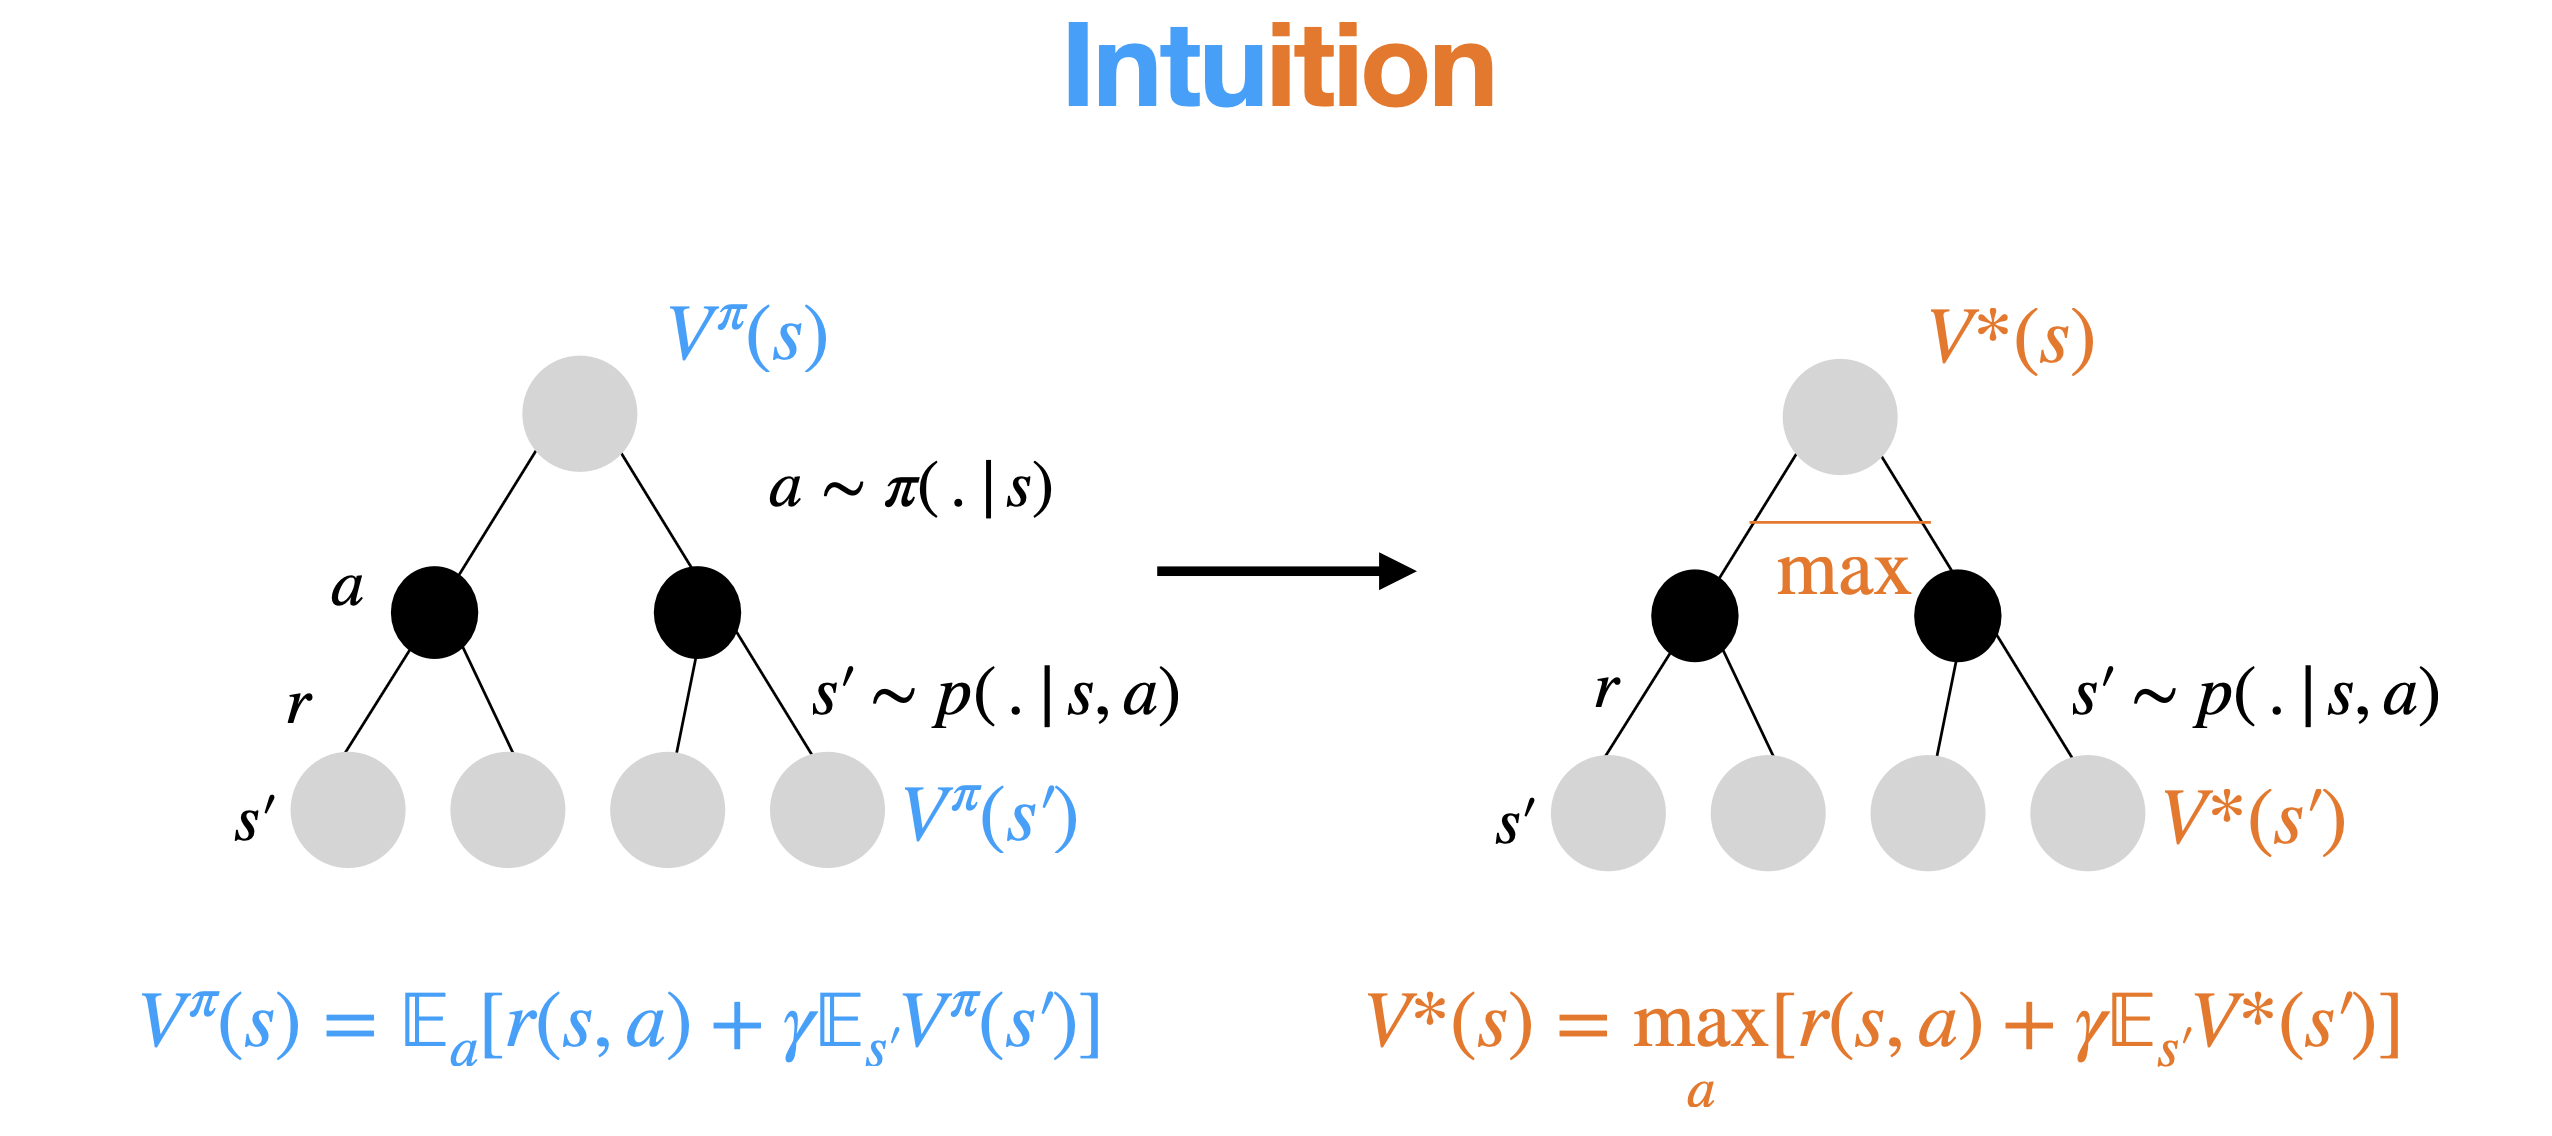

Слева мы брали действия из нашей политики, а спрва мы жадным способом выбираем действие, которое считаем оптимальным. Поэтому слева мат ожидание, а справа максимум. Дерево не изменилось - так же спускаемся по дереву не во все возможные состояния, а только в ту ветку, которая нам принесёт максимальную награду.

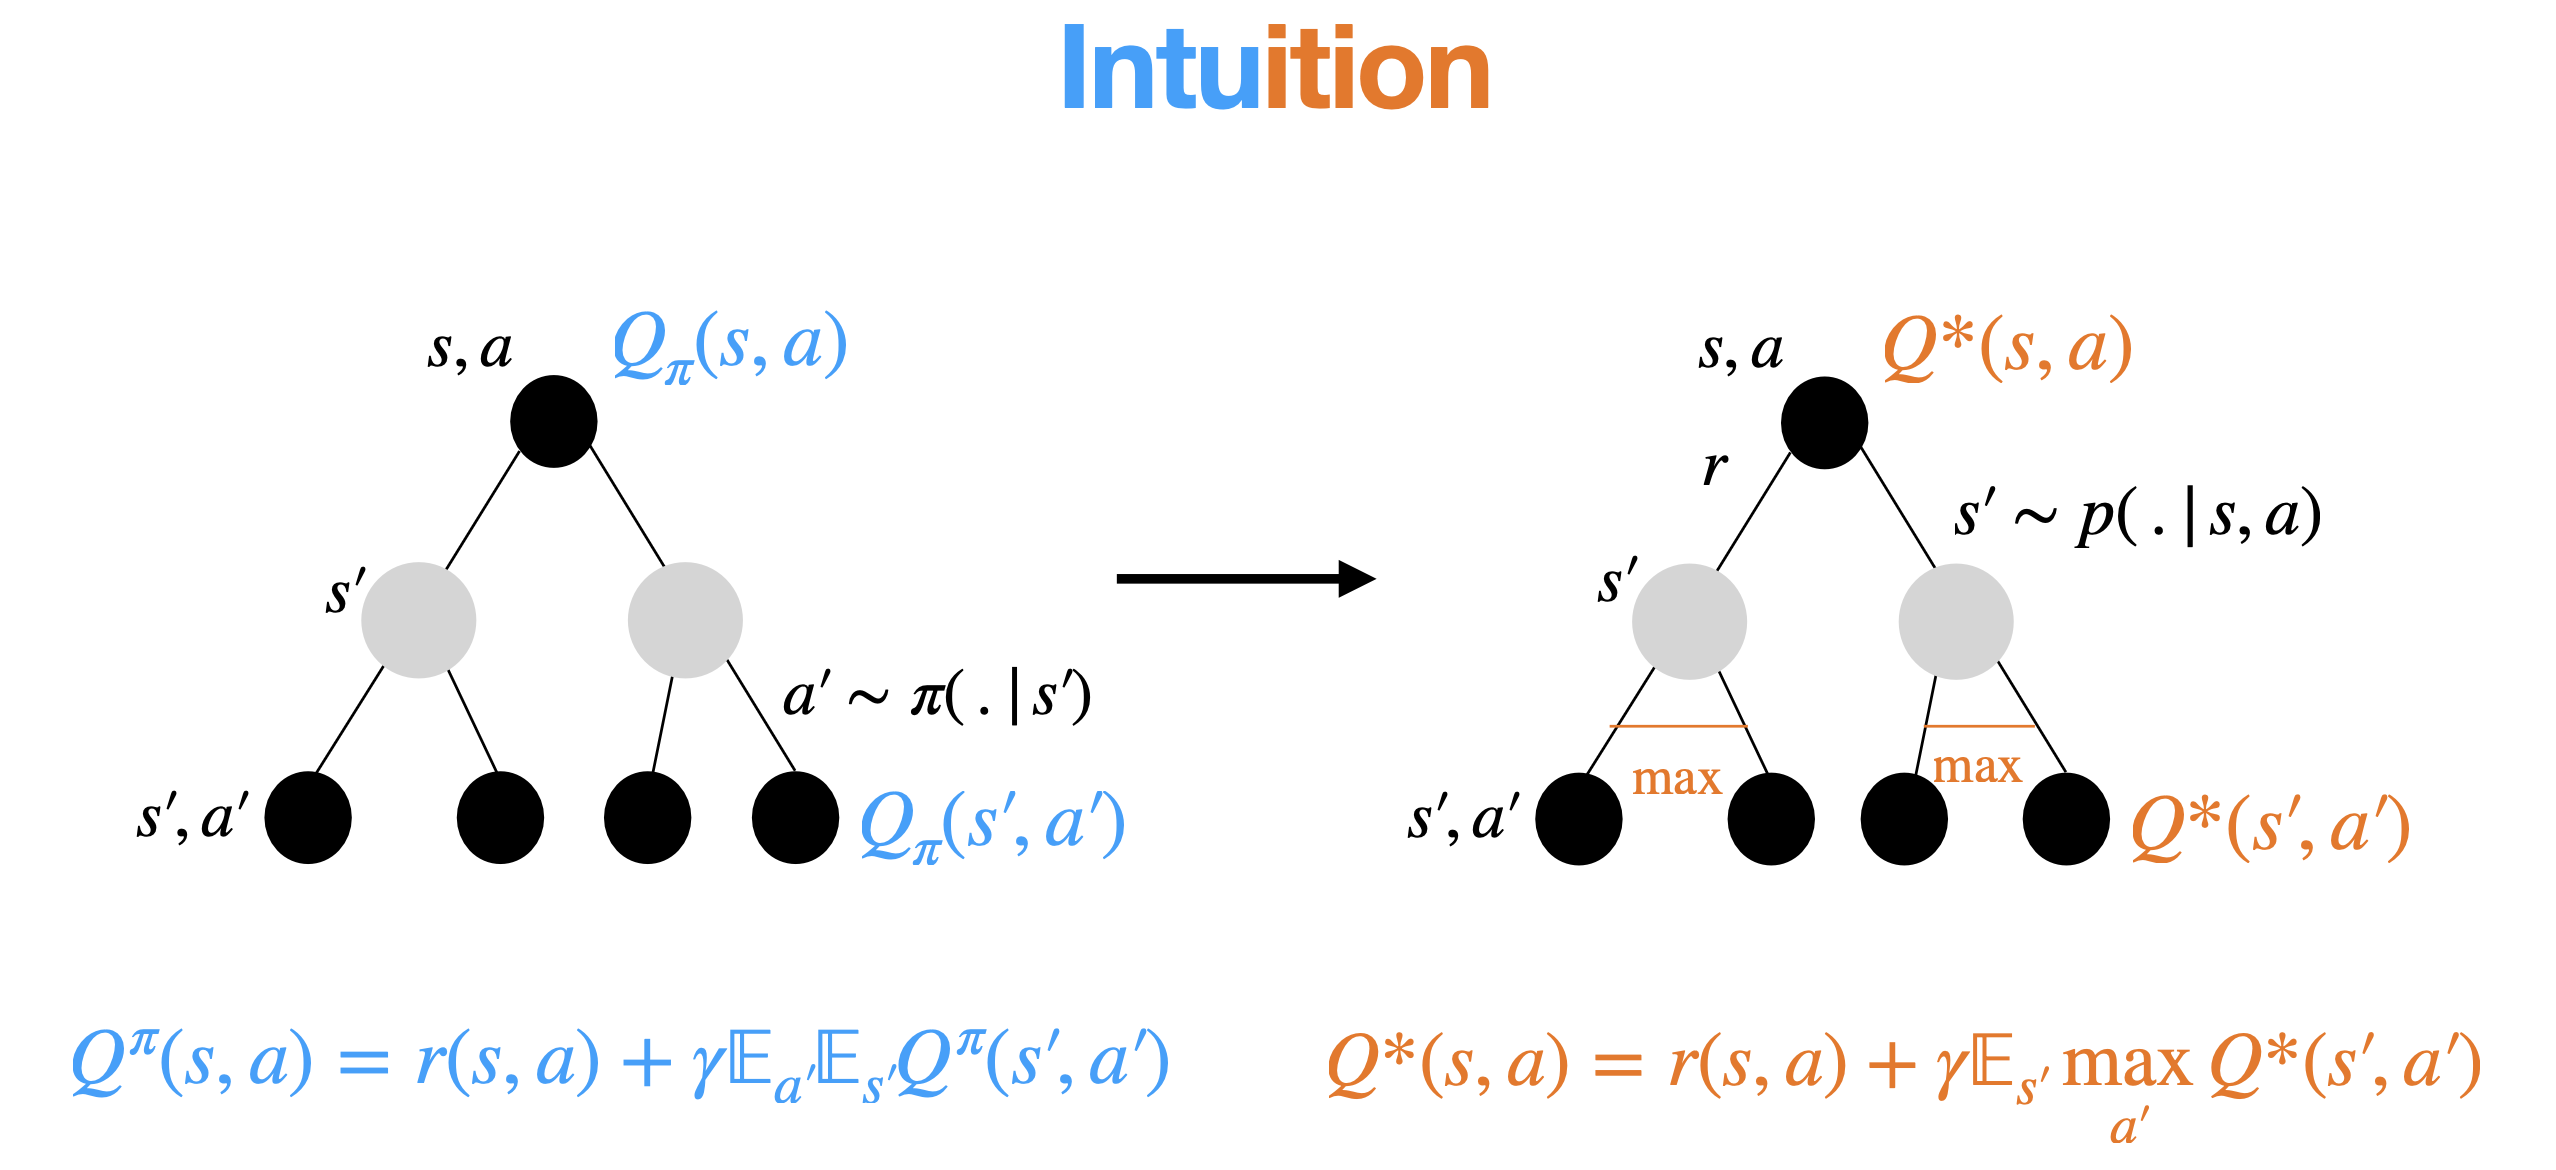

Аналогично для Q

SyntaxError: invalid syntax (203415832.py, line 1)